# Dissertation Title : Evaluating Machine Learning Models for Bank Customer Credit Risk Prediction with a Prototype Decision Support System

# Importing Libraries , Loading the Dataset and Basic Few Operations

In [ ]:
# I imported the NumPy library for numerical computations.
import numpy as np

# I imported the Pandas library for data manipulation and analysis.
import pandas as pd

# I imported the Matplotlib library for data visualization.
import matplotlib.pyplot as plt

# I imported the Seaborn library for statistical data visualization.
import seaborn as sns

# I loaded the credit risk dataset into a Pandas DataFrame.
df = pd.read_csv("credit_risk_dataset.csv")

# I displayed the first five records to understand the dataset.
print(df.head())

# I checked the number of rows and columns in the dataset.
print("\nDataset Shape:", df.shape)

# I examined the dataset information, including data types and missing values.
print("\nDataset Information:")
print(df.info())

# I generated the descriptive statistics for the numerical features.
print("\nDescriptive Statistics:")
print(df.describe())

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


# Data Inspection

In [ ]:
# I determined the total number of observations in the dataset.
num_observations = df.shape[0]

# I determined the total number of features in the dataset.
num_features = df.shape[1]

# I extracted all feature names from the dataset.
feature_names = df.columns.tolist()

# I identified the target variable.
target_variable = "loan_status"

# I identified the independent variables.
independent_variables = df.drop(columns=[target_variable]).columns.tolist()

# I identified the categories present in the target variable.
target_categories = df[target_variable].unique()

# I displayed the dataset inspection results.
print("Number of Observations :", num_observations)
print("Number of Features     :", num_features)
print("\nFeature Names:")
print(feature_names)

print("\nTarget Variable:")
print(target_variable)

print("\nIndependent Variables:")
print(independent_variables)

print("\nCategories of Target Variable:")
print(target_categories)

Number of Observations : 32581
Number of Features     : 12

Feature Names:
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']

Target Variable:
loan_status

Independent Variables:
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']

Categories of Target Variable:
[1 0]


# Data Pre-Processing

In [ ]:
# I checked the total number of missing values before preprocessing.
print("Missing Values Before Processing:")
print(df.isnull().sum())

# I identified the numerical and categorical features.
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

# I replaced the missing values in the numerical features using their median values.
for column in numerical_features:
    df[column] = df[column].fillna(df[column].median())

# I replaced the missing values in the categorical features using their mode values.
for column in categorical_features:
    df[column] = df[column].fillna(df[column].mode()[0])

# I removed duplicate records from the dataset.
df = df.drop_duplicates()

# I reset the dataset index after preprocessing.
df = df.reset_index(drop=True)

# I verified that all missing values had been handled successfully.
print("\nMissing Values After Processing:")
print(df.isnull().sum())

# I verified that duplicate records had been removed successfully.
print("\nNumber of Duplicate Records:", df.duplicated().sum())

# I displayed the updated dataset shape.
print("\nUpdated Dataset Shape:", df.shape)

# I displayed the first five records of the preprocessed dataset.
print("\nPreprocessed Dataset:")
print(df.head())

Missing Values Before Processing:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Missing Values After Processing:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

Number of Duplicate Records: 0

Updated Dataset Shape: (32416, 12)

Preprocessed Dataset:
   person_a

# Exploratory Data Analysis

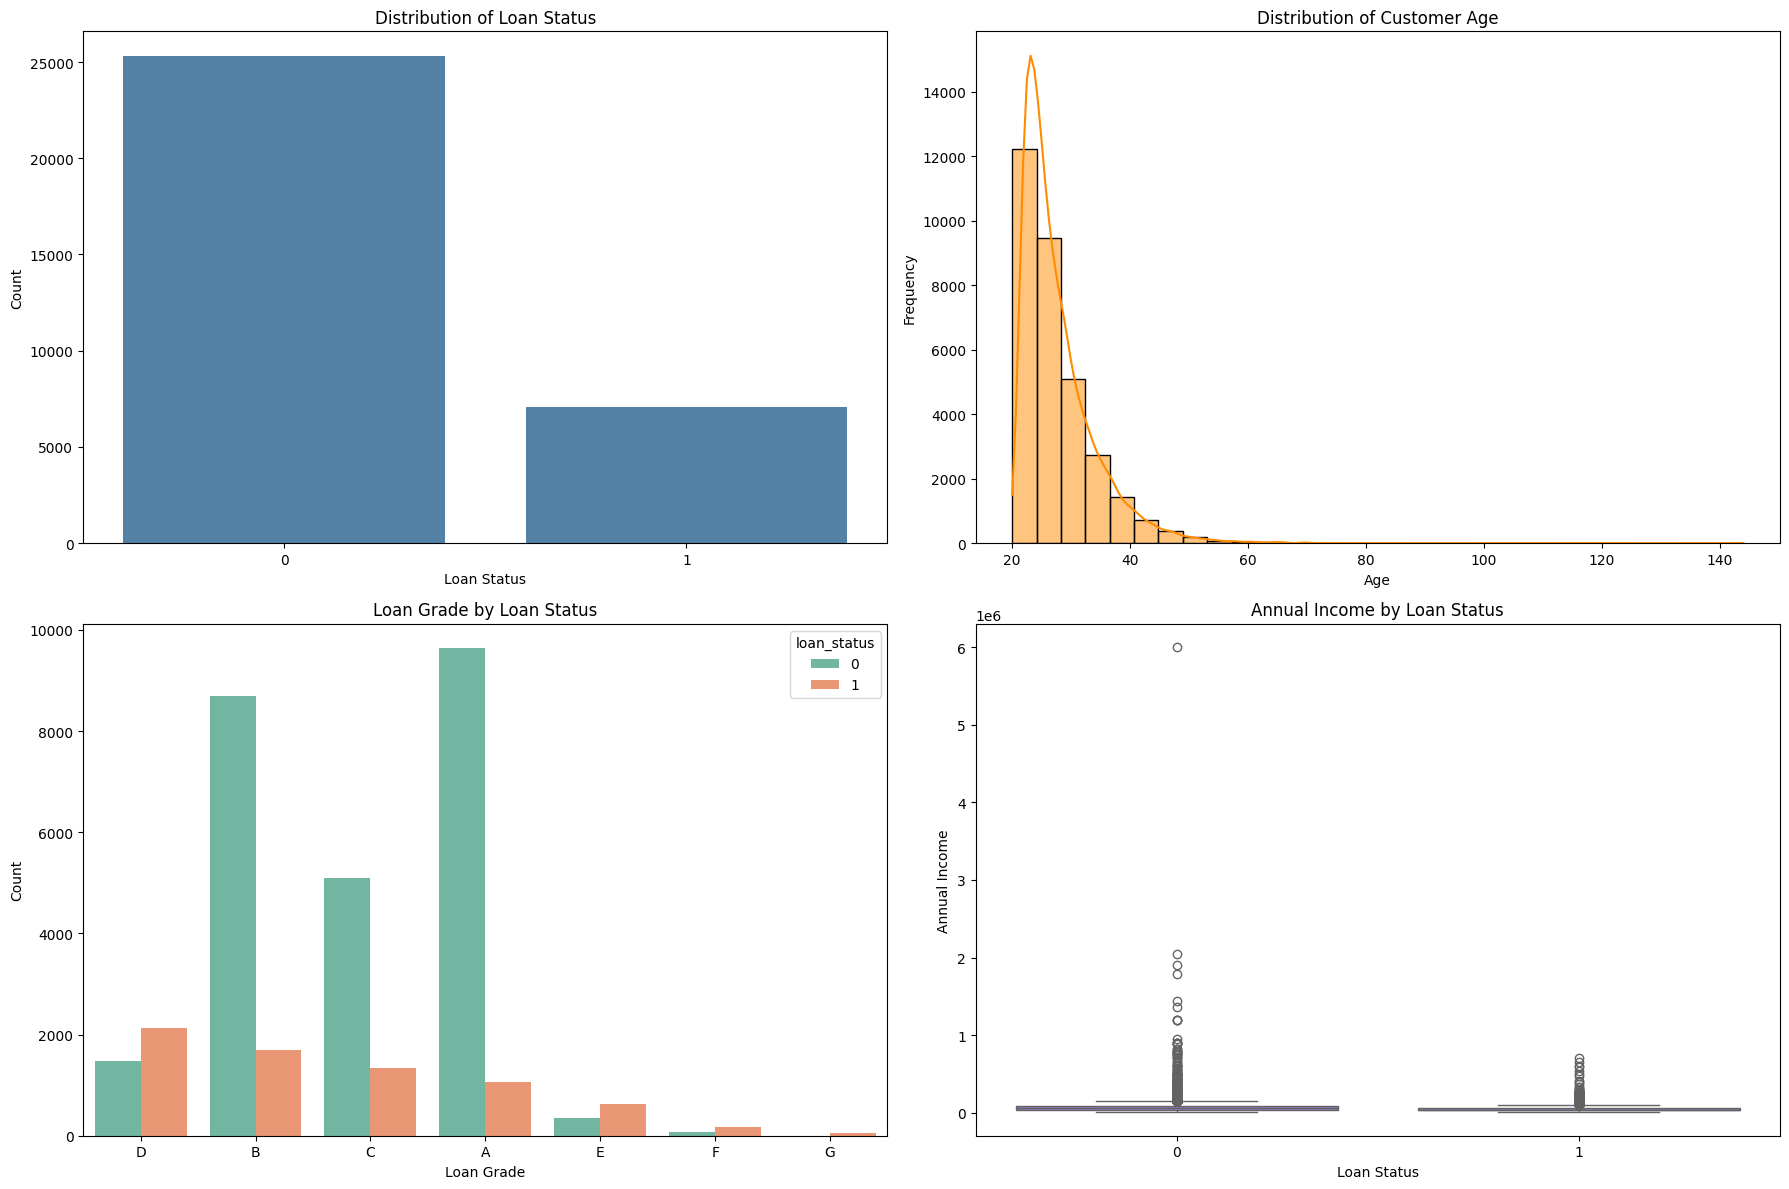

In [ ]:
# I created a figure to display multiple exploratory data analysis plots.
plt.figure(figsize=(18, 12))

# I visualized the distribution of the target variable.
plt.subplot(2, 2, 1)
sns.countplot(x='loan_status', data=df, color='steelblue')
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Count')

# I visualized the distribution of customer age.
plt.subplot(2, 2, 2)
sns.histplot(df['person_age'], bins=30, color='darkorange', kde=True)
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

# I examined the relationship between loan grade and loan status.
plt.subplot(2, 2, 3)
sns.countplot(x='loan_grade', hue='loan_status', data=df, palette='Set2')
plt.title('Loan Grade by Loan Status')
plt.xlabel('Loan Grade')
plt.ylabel('Count')

# I analysed the distribution of annual income across different loan statuses.
plt.subplot(2, 2, 4)
sns.boxplot(x='loan_status', y='person_income', data=df, color='mediumpurple')
plt.title('Annual Income by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Annual Income')

# I adjusted the layout for better visualization.
plt.tight_layout()

# I displayed all exploratory data analysis plots.
plt.show()

# Label Encoding

In [ ]:
# I imported the LabelEncoder library.
from sklearn.preprocessing import LabelEncoder

# I identified the categorical features in the dataset.
categorical_features = df.select_dtypes(include=['object']).columns

# I created a dictionary to store the fitted label encoders.
label_encoders = {}

# I converted each categorical feature into numerical values using Label Encoding.
for column in categorical_features:
    encoder = LabelEncoder()
    df[column] = encoder.fit_transform(df[column])
    label_encoders[column] = encoder

# I displayed the categorical features after encoding.
print("Categorical Features:")
print(categorical_features.tolist())

# I displayed the data types after label encoding.
print("\nData Types After Label Encoding:")
print(df.dtypes)

# I displayed the first five records of the encoded dataset.
print("\nEncoded Dataset:")
print(df.head())

Categorical Features:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

Data Types After Label Encoding:
person_age                      int64
person_income                   int64
person_home_ownership           int32
person_emp_length             float64
loan_intent                     int32
loan_grade                      int32
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file       int32
cb_person_cred_hist_length      int64
dtype: object

Encoded Dataset:
   person_age  person_income  person_home_ownership  person_emp_length  \
0          22          59000                      3              123.0   
1          21           9600                      2                5.0   
2          25           9600                      0                1.0   
3          23          65500                      3                4.0   
4 

# Splitting the Dataset

In [ ]:
# I imported the train-test split function.
from sklearn.model_selection import train_test_split

# I separated the independent and target variables.
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# I divided the dataset into training and testing datasets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# I displayed the dimensions of the training and testing datasets.
print("Training Feature Set Shape :", X_train.shape)
print("Testing Feature Set Shape  :", X_test.shape)
print("Training Target Set Shape  :", y_train.shape)
print("Testing Target Set Shape   :", y_test.shape)

# I displayed the class distribution in the training dataset.
print("\nTraining Class Distribution:")
print(y_train.value_counts())

Training Feature Set Shape : (25932, 11)
Testing Feature Set Shape  : (6484, 11)
Training Target Set Shape  : (25932,)
Testing Target Set Shape   : (6484,)

Training Class Distribution:
loan_status
0    20261
1     5671
Name: count, dtype: int64


# Class Imbalance Using SMOTE

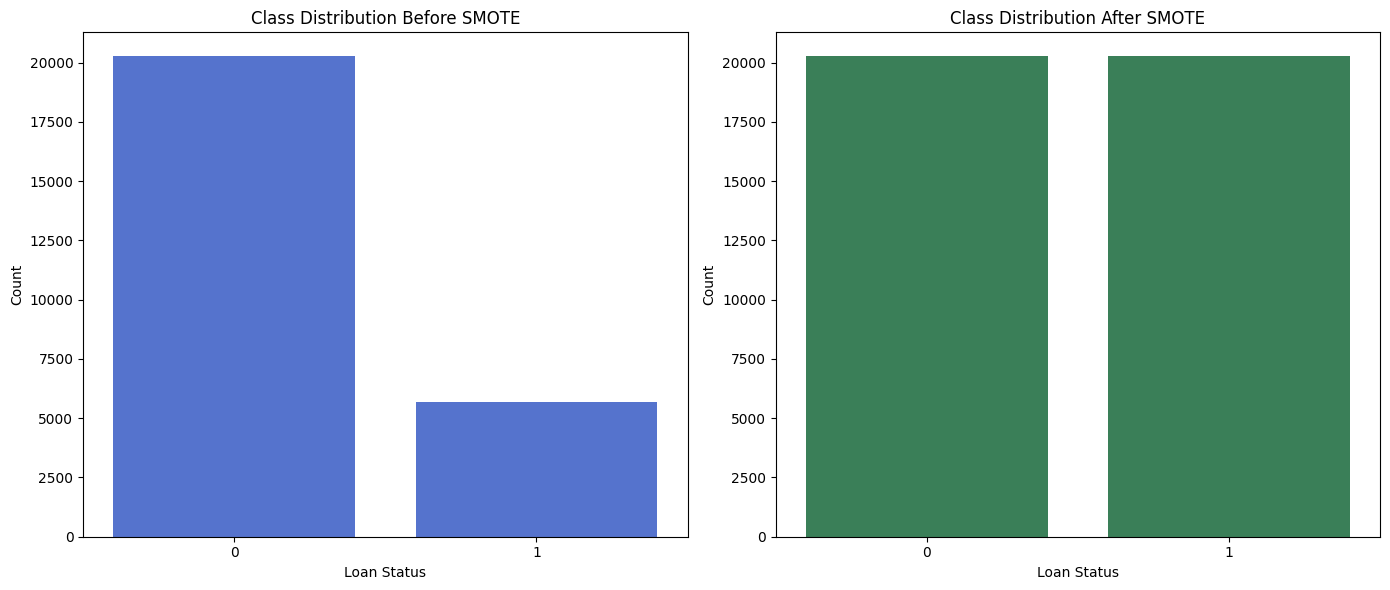

Class Distribution After SMOTE:
loan_status
0    20261
1    20261
Name: count, dtype: int64

Balanced Training Feature Set Shape : (40522, 11)
Balanced Testing Feature Set Shape  : (6484, 11)
Balanced Training Target Set Shape  : (40522,)
Testing Target Set Shape            : (6484,)


In [ ]:
# I imported the SMOTE library.
from imblearn.over_sampling import SMOTE

# I created a figure to compare the class distribution before and after applying SMOTE.
plt.figure(figsize=(14,6))

# I visualised the class distribution before applying SMOTE.
plt.subplot(1,2,1)
sns.countplot(x=y_train, color='royalblue')
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Loan Status")
plt.ylabel("Count")

# I created an instance of the SMOTE technique.
smote = SMOTE(random_state=42)

# I balanced the training dataset using SMOTE.
X_train, y_train = smote.fit_resample(X_train, y_train)

# I visualised the class distribution after applying SMOTE.
plt.subplot(1,2,2)
sns.countplot(x=y_train, color='seagreen')
plt.title("Class Distribution After SMOTE")
plt.xlabel("Loan Status")
plt.ylabel("Count")

# I adjusted the layout for better visualization.
plt.tight_layout()

# I displayed the comparison plots.
plt.show()

# I displayed the balanced class distribution.
print("Class Distribution After SMOTE:")
print(y_train.value_counts())

# I displayed the dimensions of the balanced training dataset.
print("\nBalanced Training Feature Set Shape :", X_train.shape)
print("Balanced Testing Feature Set Shape  :", X_test.shape)
print("Balanced Training Target Set Shape  :", y_train.shape)
print("Testing Target Set Shape            :", y_test.shape)

# Model Selection , Training & Evaluation

# Baseline Models (Before Hyper Parameter Tuning )

# 1. XGBoost

In [ ]:
# I imported the required libraries for the XGBoost classifier and model evaluation.
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# I created an instance of the XGBoost classifier.
baseline_xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

# I trained the XGBoost model using the balanced training dataset.
baseline_xgb.fit(X_train, y_train)

# I predicted the class labels for the testing dataset.
y_pred = baseline_xgb.predict(X_test)

# I predicted the class probabilities for the testing dataset.
y_prob = baseline_xgb.predict_proba(X_test)[:, 1]

# I calculated the evaluation metrics.
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# I stored the evaluation metrics for later model comparison.
bas_xgb_metric = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "ROC-AUC": roc_auc
}

# I displayed the evaluation metrics.
print("Baseline XGBoost Performance")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

# I displayed the stored evaluation metrics.
print("\nStored Metrics:")
print(bas_xgb_metric)

Baseline XGBoost Performance
Accuracy : 0.9320
Precision: 0.9215
Recall   : 0.7532
F1-Score : 0.8289
ROC-AUC  : 0.9362

Stored Metrics:
{'Accuracy': 0.9319864281307835, 'Precision': 0.9214840379637619, 'Recall': 0.7531734837799718, 'F1-Score': 0.8288707799767171, 'ROC-AUC': 0.9361537020218864}


# 2. LightGBM

In [ ]:
# I imported the required libraries for the LightGBM classifier and model evaluation.
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# I created an instance of the LightGBM classifier.
baseline_lgbm = LGBMClassifier(random_state=42)

# I trained the LightGBM model using the balanced training dataset.
baseline_lgbm.fit(X_train, y_train)

# I predicted the class labels for the testing dataset.
y_pred = baseline_lgbm.predict(X_test)

# I predicted the class probabilities for the testing dataset.
y_prob = baseline_lgbm.predict_proba(X_test)[:, 1]

# I calculated the evaluation metrics.
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# I stored the evaluation metrics for later model comparison.
bas_lgbm_metric = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "ROC-AUC": roc_auc
}

# I displayed the evaluation metrics.
print("Baseline LightGBM Performance")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

# I displayed the stored evaluation metrics.
print("\nStored Metrics:")
print(bas_lgbm_metric)

[LightGBM] [Info] Number of positive: 20261, number of negative: 20261
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.028259 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1376
[LightGBM] [Info] Number of data points in the train set: 40522, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Baseline LightGBM Performance
Accuracy : 0.9281
Precision: 0.9139
Recall   : 0.7412
F1-Score : 0.8185
ROC-AUC  : 0.9345

Stored Metrics:
{'Accuracy': 0.9281307834669957, 'Precision': 0.9139130434782609, 'Recall': 0.7411847672778561, 'F1-Score': 0.8185358255451712, 'ROC-AUC': 0.9345178203427033}


# 3. Random Forest

In [ ]:
# I imported the required libraries for the Random Forest classifier and model evaluation.
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# I created an instance of the Random Forest classifier.
baseline_rf = RandomForestClassifier(random_state=42)

# I trained the Random Forest model using the balanced training dataset.
baseline_rf.fit(X_train, y_train)

# I predicted the class labels for the testing dataset.
y_pred = baseline_rf.predict(X_test)

# I predicted the class probabilities for the testing dataset.
y_prob = baseline_rf.predict_proba(X_test)[:, 1]

# I calculated the evaluation metrics.
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# I stored the evaluation metrics for later model comparison.
bas_rf_metric = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "ROC-AUC": roc_auc
}

# I displayed the evaluation metrics.
print("Baseline Random Forest Performance")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

# I displayed the stored evaluation metrics.
print("\nStored Metrics:")
print(bas_rf_metric)

Baseline Random Forest Performance
Accuracy : 0.9039
Precision: 0.7951
Recall   : 0.7553
F1-Score : 0.7747
ROC-AUC  : 0.9188

Stored Metrics:
{'Accuracy': 0.9039173349784084, 'Precision': 0.7951002227171492, 'Recall': 0.7552891396332864, 'F1-Score': 0.7746835443037976, 'ROC-AUC': 0.9187681698894758}


# 4. CatBoost

In [ ]:
# I imported the required libraries for the CatBoost classifier and model evaluation.
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# I created an instance of the CatBoost classifier.
baseline_cat = CatBoostClassifier(
    random_state=42,
    verbose=0
)

# I trained the CatBoost model using the balanced training dataset.
baseline_cat.fit(X_train, y_train)

# I predicted the class labels for the testing dataset.
y_pred = baseline_cat.predict(X_test)

# I predicted the class probabilities for the testing dataset.
y_prob = baseline_cat.predict_proba(X_test)[:, 1]

# I calculated the evaluation metrics.
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# I stored the evaluation metrics for later model comparison.
bas_cat_metric = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "ROC-AUC": roc_auc
}

# I displayed the evaluation metrics.
print("Baseline CatBoost Performance")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

# I displayed the stored evaluation metrics.
print("\nStored Metrics:")
print(bas_cat_metric)

Baseline CatBoost Performance
Accuracy : 0.9354
Precision: 0.9520
Recall   : 0.7419
F1-Score : 0.8339
ROC-AUC  : 0.9388

Stored Metrics:
{'Accuracy': 0.9353793954349168, 'Precision': 0.9520361990950226, 'Recall': 0.7418899858956276, 'F1-Score': 0.8339278636543797, 'ROC-AUC': 0.9388467155967185}


# Combined Comparative Table for all Baseline Models

In [ ]:
# I created a comparative performance table for the baseline machine learning models.
baseline_comparison = pd.DataFrame({
    "Model": [
        "XGBoost",
        "LightGBM",
        "Random Forest",
        "CatBoost"
    ],
    "Accuracy": [
        bas_xgb_metric["Accuracy"],
        bas_lgbm_metric["Accuracy"],
        bas_rf_metric["Accuracy"],
        bas_cat_metric["Accuracy"]
    ],
    "Precision": [
        bas_xgb_metric["Precision"],
        bas_lgbm_metric["Precision"],
        bas_rf_metric["Precision"],
        bas_cat_metric["Precision"]
    ],
    "Recall": [
        bas_xgb_metric["Recall"],
        bas_lgbm_metric["Recall"],
        bas_rf_metric["Recall"],
        bas_cat_metric["Recall"]
    ],
    "F1-Score": [
        bas_xgb_metric["F1-Score"],
        bas_lgbm_metric["F1-Score"],
        bas_rf_metric["F1-Score"],
        bas_cat_metric["F1-Score"]
    ],
    "ROC-AUC": [
        bas_xgb_metric["ROC-AUC"],
        bas_lgbm_metric["ROC-AUC"],
        bas_rf_metric["ROC-AUC"],
        bas_cat_metric["ROC-AUC"]
    ]
})

# I rounded the evaluation metrics to four decimal places.
baseline_comparison = baseline_comparison.round(4)

# I assigned different colours to each model.
def highlight_models(row):
    if row["Model"] == "XGBoost":
        return ["background-color:#D6EAF8"] * len(row)      # Light Blue
    elif row["Model"] == "LightGBM":
        return ["background-color:#D5F5E3"] * len(row)      # Light Green
    elif row["Model"] == "Random Forest":
        return ["background-color:#FCF3CF"] * len(row)      # Light Yellow
    elif row["Model"] == "CatBoost":
        return ["background-color:#FADBD8"] * len(row)      # Light Red
    else:
        return [""] * len(row)

# I displayed the styled comparative performance table.
baseline_comparison.style\
    .apply(highlight_models, axis=1)\
    .hide(axis="index")\
    .set_caption("Baseline Machine Learning Model Performance Comparison")\
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })\
    .set_properties(**{
        "text-align": "center",
        "font-size": "12pt",
        "border": "1px solid black"
    })\
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("color", "#1F4E78"),
                ("text-align", "center"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E78"),
                ("color", "white"),
                ("font-size", "13pt"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid black")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("border", "1px solid black"),
                ("font-size", "12pt")
            ]
        }
    ])

Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
XGBoost,0.9320,0.9215,0.7532,0.8289,0.9362
LightGBM,0.9281,0.9139,0.7412,0.8185,0.9345
Random Forest,0.9039,0.7951,0.7553,0.7747,0.9188
CatBoost,0.9354,0.9520,0.7419,0.8339,0.9388


# Visualisations for Each Metric : Baseline Models

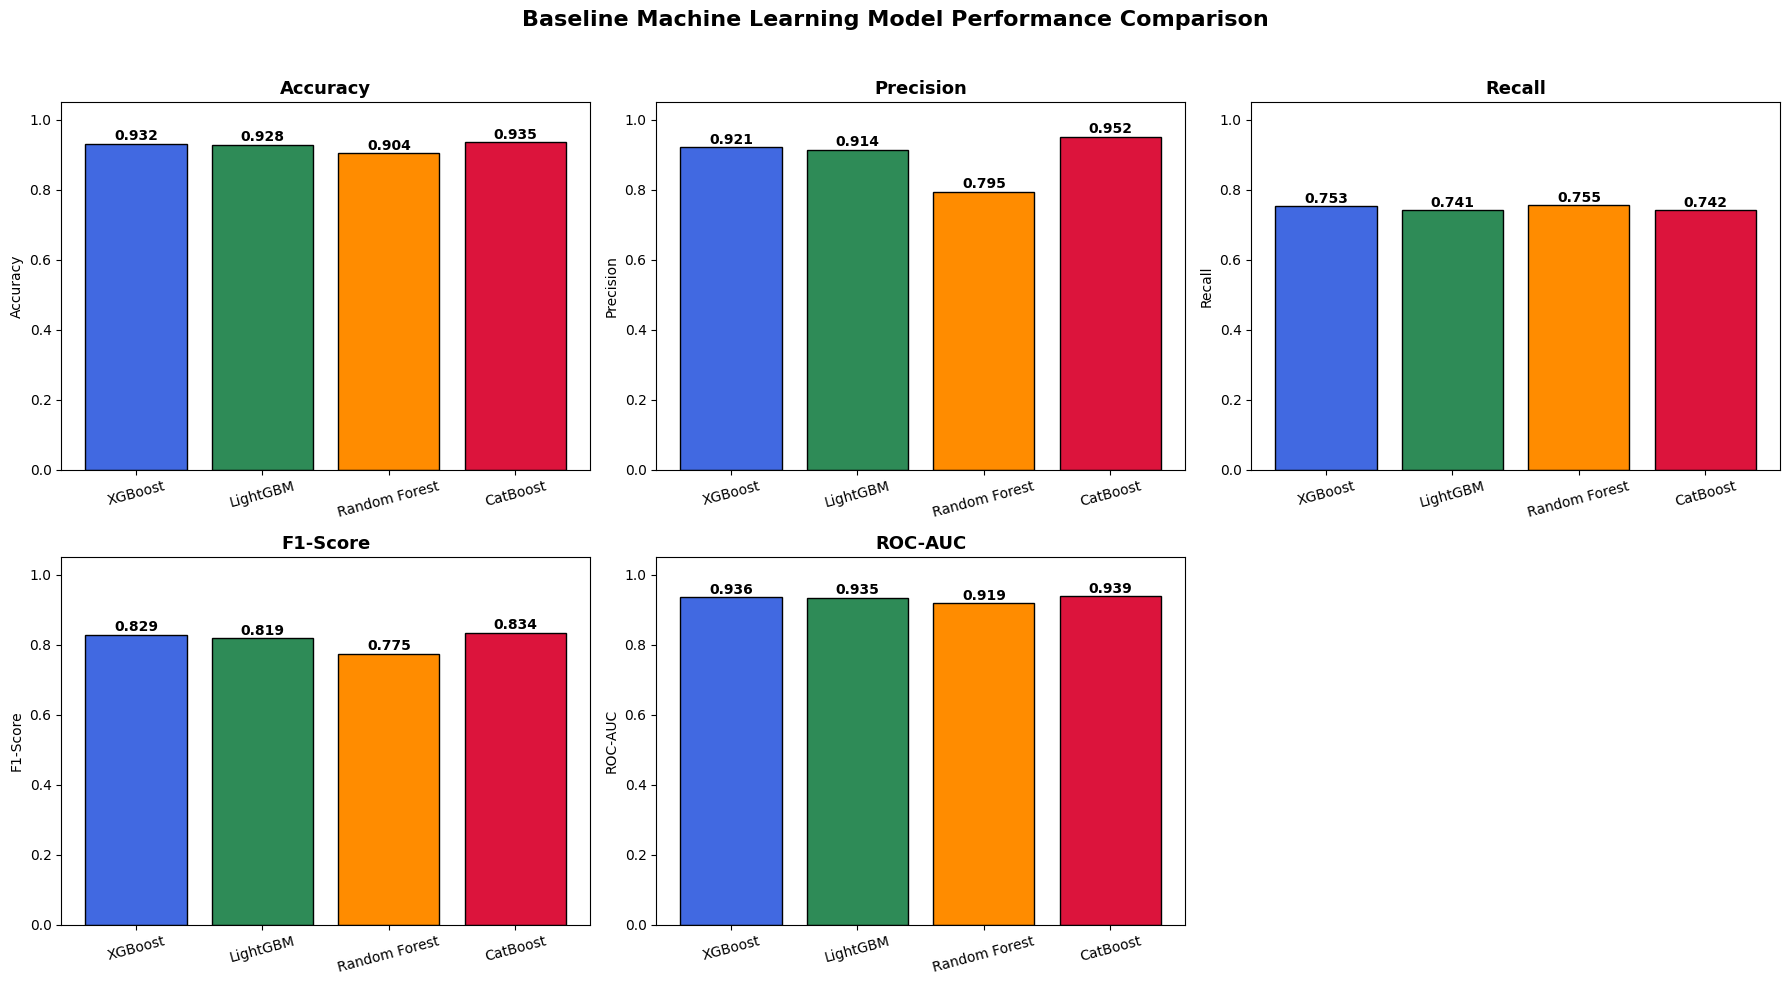

In [ ]:
# I created a dictionary containing the evaluation metrics of all baseline models.
baseline_metrics = {
    "XGBoost": bas_xgb_metric,
    "LightGBM": bas_lgbm_metric,
    "Random Forest": bas_rf_metric,
    "CatBoost": bas_cat_metric
}

# I assigned different colours to each machine learning model.
model_colours = {
    "XGBoost": "royalblue",
    "LightGBM": "seagreen",
    "Random Forest": "darkorange",
    "CatBoost": "crimson"
}

# I defined the evaluation metrics to be visualised.
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

# I created multiple bar charts to compare the baseline model performance.
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):

    models = list(baseline_metrics.keys())
    values = [baseline_metrics[model][metric] for model in models]
    colours = [model_colours[model] for model in models]

    bars = axes[i].bar(models, values, color=colours, edgecolor='black')

    axes[i].set_title(metric, fontsize=13, fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0, 1.05)
    axes[i].tick_params(axis='x', rotation=15)

    # I displayed the metric values above each bar.
    for bar in bars:
        height = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height:.3f}",
            ha='center',
            fontsize=10,
            fontweight='bold'
        )

# I removed the unused subplot.
fig.delaxes(axes[5])

# I added a title to the complete figure.
plt.suptitle(
    "Baseline Machine Learning Model Performance Comparison",
    fontsize=16,
    fontweight='bold'
)

# I adjusted the layout for better visualisation.
plt.tight_layout(rect=[0, 0, 1, 0.96])

# I displayed the comparison graphs.
plt.show()

# Combined Comparative Bar Graph for all Baseline Models

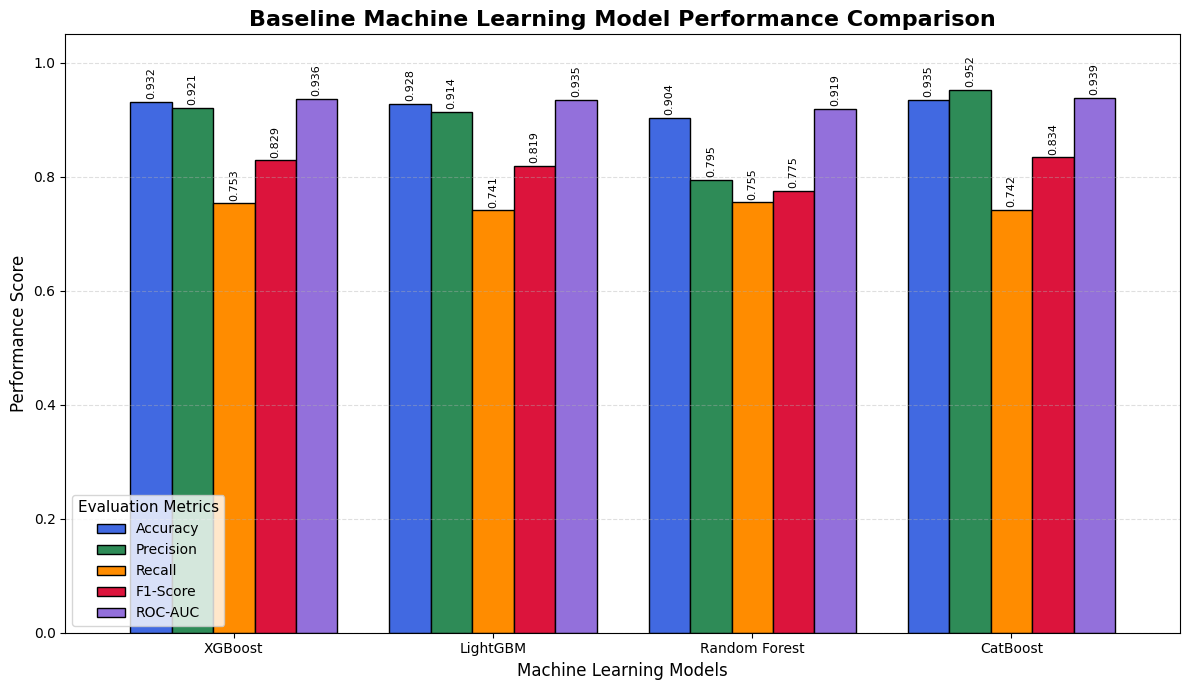

In [ ]:
# I created a comparative performance dataset for the baseline machine learning models.
comparison_df = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM", "Random Forest", "CatBoost"],
    "Accuracy": [
        bas_xgb_metric["Accuracy"],
        bas_lgbm_metric["Accuracy"],
        bas_rf_metric["Accuracy"],
        bas_cat_metric["Accuracy"]
    ],
    "Precision": [
        bas_xgb_metric["Precision"],
        bas_lgbm_metric["Precision"],
        bas_rf_metric["Precision"],
        bas_cat_metric["Precision"]
    ],
    "Recall": [
        bas_xgb_metric["Recall"],
        bas_lgbm_metric["Recall"],
        bas_rf_metric["Recall"],
        bas_cat_metric["Recall"]
    ],
    "F1-Score": [
        bas_xgb_metric["F1-Score"],
        bas_lgbm_metric["F1-Score"],
        bas_rf_metric["F1-Score"],
        bas_cat_metric["F1-Score"]
    ],
    "ROC-AUC": [
        bas_xgb_metric["ROC-AUC"],
        bas_lgbm_metric["ROC-AUC"],
        bas_rf_metric["ROC-AUC"],
        bas_cat_metric["ROC-AUC"]
    ]
})

# I created a grouped bar chart for comparing all baseline models.
ax = comparison_df.set_index("Model").plot(
    kind="bar",
    figsize=(12,7),
    width=0.8,
    color=["royalblue", "seagreen", "darkorange", "crimson", "mediumpurple"],
    edgecolor="black"
)

# I customised the chart.
plt.title(
    "Baseline Machine Learning Model Performance Comparison",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Machine Learning Models", fontsize=12)
plt.ylabel("Performance Score", fontsize=12)
plt.ylim(0, 1.05)

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

# I displayed the legend.
plt.legend(
    title="Evaluation Metrics",
    fontsize=10,
    title_fontsize=11,
    loc="lower left"
)

# I displayed the metric values above each bar.
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        fontsize=8,
        rotation=90,
        padding=2
    )

# I adjusted the layout.
plt.tight_layout()

# I displayed the grouped bar chart.
plt.show()

# Combined Comparative Bar Graph (F1-Score ) for all Baseline Models

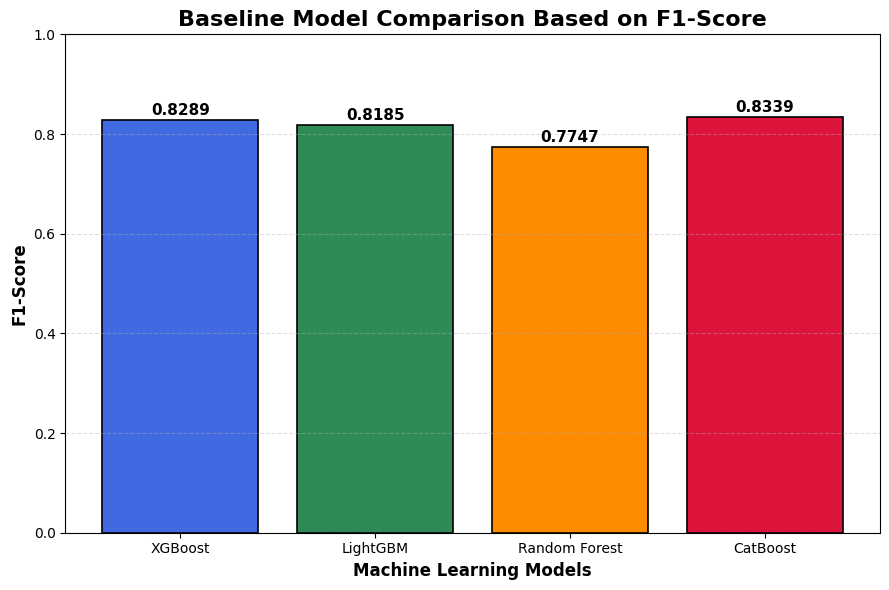

In [ ]:
# I created the F1-Score values for all baseline machine learning models.
models = ["XGBoost", "LightGBM", "Random Forest", "CatBoost"]

f1_scores = [
    bas_xgb_metric["F1-Score"],
    bas_lgbm_metric["F1-Score"],
    bas_rf_metric["F1-Score"],
    bas_cat_metric["F1-Score"]
]

# I assigned different colours to each model.
colours = [
    "royalblue",
    "seagreen",
    "darkorange",
    "crimson"
]

# I created the F1-Score comparison bar chart.
plt.figure(figsize=(9,6))

bars = plt.bar(
    models,
    f1_scores,
    color=colours,
    edgecolor="black",
    linewidth=1.2
)

# I displayed the F1-Score values above each bar.
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.4f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# I customised the graph.
plt.title(
    "Baseline Model Comparison Based on F1-Score",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Machine Learning Models",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "F1-Score",
    fontsize=12,
    fontweight="bold"
)

plt.ylim(0, 1.0)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

# I displayed the graph.
plt.show()

# Confusion Matrices for all Baseline Models

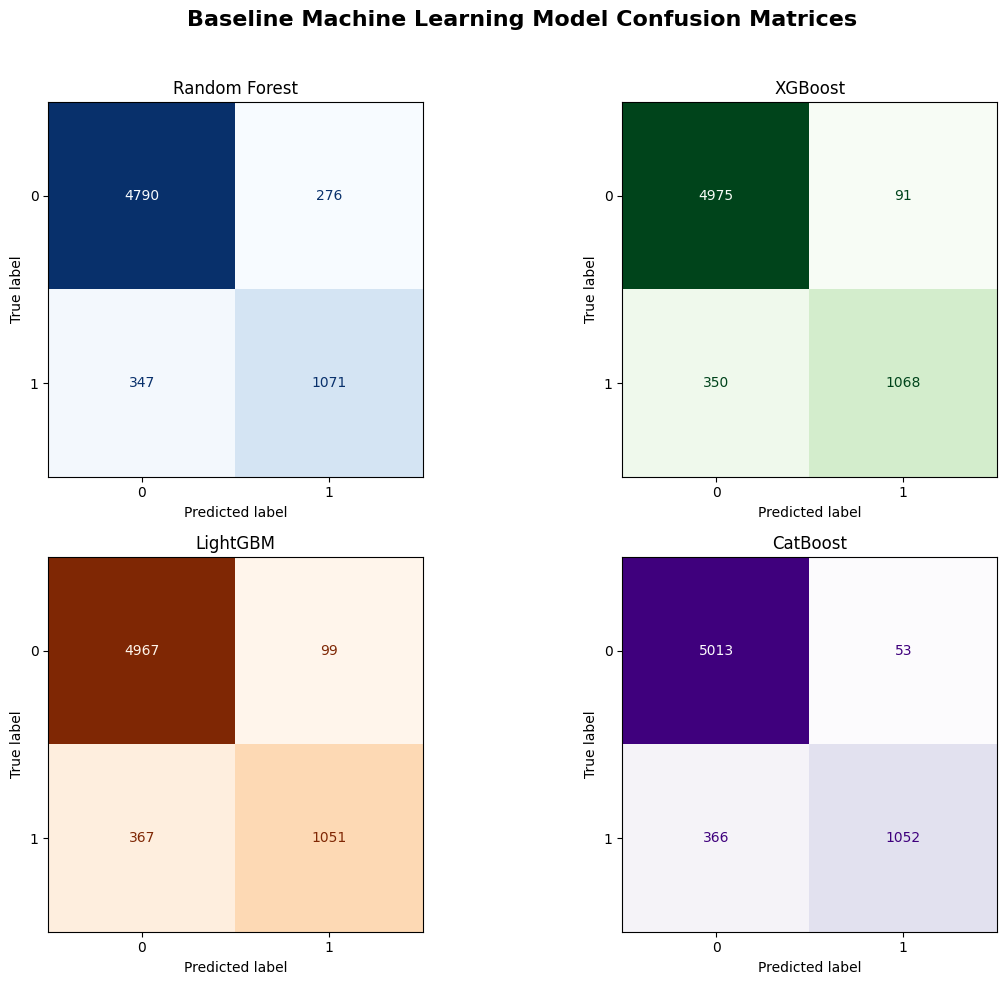

In [ ]:
# I imported the confusion matrix library.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# I created predictions for each baseline machine learning model.
rf_pred = baseline_rf.predict(X_test)
xgb_pred = baseline_xgb.predict(X_test)
lgbm_pred = baseline_lgbm.predict(X_test)
cat_pred = baseline_cat.predict(X_test)

# I calculated the confusion matrices.
rf_cm = confusion_matrix(y_test, rf_pred)
xgb_cm = confusion_matrix(y_test, xgb_pred)
lgbm_cm = confusion_matrix(y_test, lgbm_pred)
cat_cm = confusion_matrix(y_test, cat_pred)

# I created a figure to display all confusion matrices.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# I displayed the Random Forest confusion matrix.
ConfusionMatrixDisplay(rf_cm).plot(
    ax=axes[0,0],
    cmap="Blues",
    colorbar=False
)
axes[0,0].set_title("Random Forest")

# I displayed the XGBoost confusion matrix.
ConfusionMatrixDisplay(xgb_cm).plot(
    ax=axes[0,1],
    cmap="Greens",
    colorbar=False
)
axes[0,1].set_title("XGBoost")

# I displayed the LightGBM confusion matrix.
ConfusionMatrixDisplay(lgbm_cm).plot(
    ax=axes[1,0],
    cmap="Oranges",
    colorbar=False
)
axes[1,0].set_title("LightGBM")

# I displayed the CatBoost confusion matrix.
ConfusionMatrixDisplay(cat_cm).plot(
    ax=axes[1,1],
    cmap="Purples",
    colorbar=False
)
axes[1,1].set_title("CatBoost")

# I added a title to the figure.
plt.suptitle(
    "Baseline Machine Learning Model Confusion Matrices",
    fontsize=16,
    fontweight="bold"
)

# I adjusted the layout.
plt.tight_layout(rect=[0,0,1,0.96])

# I displayed the confusion matrices.
plt.show()

# Combined Comparative AUC-ROC Curve for all Baseline Models

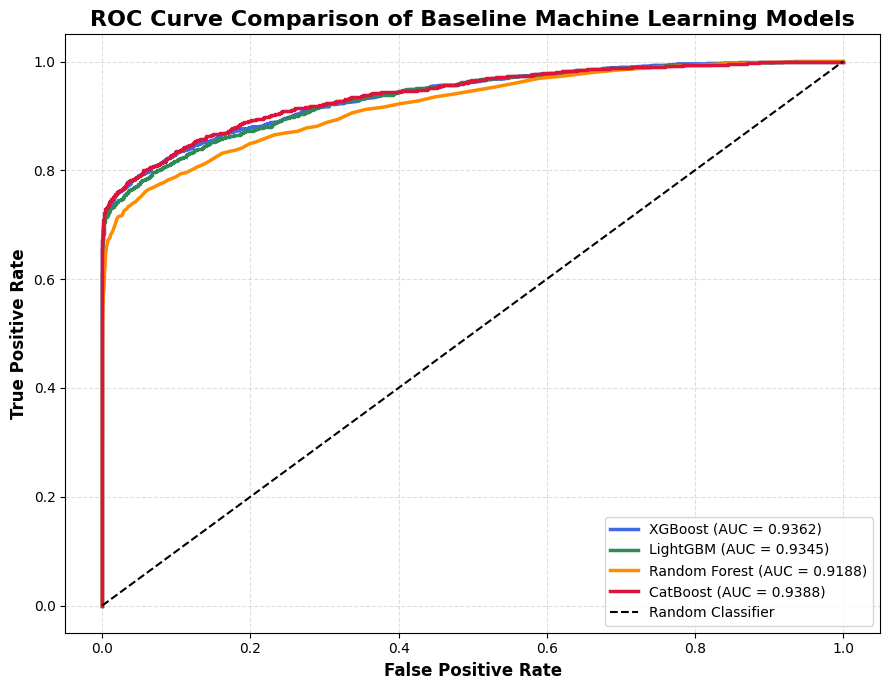

In [ ]:
# I imported the required libraries for plotting the ROC curves.
from sklearn.metrics import roc_curve, auc

# I predicted the probabilities for each baseline machine learning model.
rf_prob = baseline_rf.predict_proba(X_test)[:, 1]
xgb_prob = baseline_xgb.predict_proba(X_test)[:, 1]
lgbm_prob = baseline_lgbm.predict_proba(X_test)[:, 1]
cat_prob = baseline_cat.predict_proba(X_test)[:, 1]

# I calculated the ROC curve and AUC for the Random Forest model.
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
rf_auc = auc(rf_fpr, rf_tpr)

# I calculated the ROC curve and AUC for the XGBoost model.
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)
xgb_auc = auc(xgb_fpr, xgb_tpr)

# I calculated the ROC curve and AUC for the LightGBM model.
lgbm_fpr, lgbm_tpr, _ = roc_curve(y_test, lgbm_prob)
lgbm_auc = auc(lgbm_fpr, lgbm_tpr)

# I calculated the ROC curve and AUC for the CatBoost model.
cat_fpr, cat_tpr, _ = roc_curve(y_test, cat_prob)
cat_auc = auc(cat_fpr, cat_tpr)

# I created the combined ROC curve.
plt.figure(figsize=(9,7))

plt.plot(
    xgb_fpr,
    xgb_tpr,
    color="royalblue",
    linewidth=2.5,
    label=f"XGBoost (AUC = {xgb_auc:.4f})"
)

plt.plot(
    lgbm_fpr,
    lgbm_tpr,
    color="seagreen",
    linewidth=2.5,
    label=f"LightGBM (AUC = {lgbm_auc:.4f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    color="darkorange",
    linewidth=2.5,
    label=f"Random Forest (AUC = {rf_auc:.4f})"
)

plt.plot(
    cat_fpr,
    cat_tpr,
    color="crimson",
    linewidth=2.5,
    label=f"CatBoost (AUC = {cat_auc:.4f})"
)

# I plotted the random classifier reference line.
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="Random Classifier"
)

# I customised the graph.
plt.title(
    "ROC Curve Comparison of Baseline Machine Learning Models",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12,
    fontweight="bold"
)

plt.legend(
    loc="lower right",
    fontsize=10,
    frameon=True
)

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

# I displayed the ROC curve.
plt.show()

# Hyper Parameter Tuning

# 1. Tuned XGBoost

In [ ]:
# I imported the required libraries for XGBoost hyperparameter optimisation.
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# I defined the hyperparameter search space.
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

# I created an instance of the XGBoost classifier.
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

# I created an instance of the Randomized Search Cross Validation.
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# I performed hyperparameter optimisation.
random_search.fit(X_train, y_train)

# I selected the best XGBoost model.
best_xgb = random_search.best_estimator_

# I predicted the class labels for the testing dataset.
y_pred = best_xgb.predict(X_test)

# I predicted the class probabilities for the testing dataset.
y_prob = best_xgb.predict_proba(X_test)[:, 1]

# I calculated the evaluation metrics.
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# I stored the evaluation metrics for later model comparison.
tun_xg_metric = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "ROC-AUC": roc_auc
}

# I displayed the best hyperparameters.
print("Best Hyperparameters:")
print(random_search.best_params_)

# I displayed the evaluation metrics.
print("\nOptimised XGBoost Performance")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

# I displayed the stored evaluation metrics.
print("\nStored Metrics:")
print(tun_xg_metric)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Hyperparameters:
{'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05}

Optimised XGBoost Performance
Accuracy : 0.9283
Precision: 0.9104
Recall   : 0.7454
F1-Score : 0.8197
ROC-AUC  : 0.9346

Stored Metrics:
{'Accuracy': 0.9282850092535472, 'Precision': 0.9104220499569337, 'Recall': 0.7454160789844851, 'F1-Score': 0.8196975571927103, 'ROC-AUC': 0.9345609742652279}


# 2. Tuned LightGBM

In [ ]:
# I imported the required libraries for LightGBM hyperparameter optimisation.
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# I defined the hyperparameter search space.
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 70]
}

# I created an instance of the LightGBM classifier.
lgbm = LGBMClassifier(random_state=42)

# I created an instance of the Randomized Search Cross Validation.
random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# I performed hyperparameter optimisation.
random_search.fit(X_train, y_train)

# I selected the best LightGBM model.
best_lgbm = random_search.best_estimator_

# I predicted the class labels for the testing dataset.
y_pred = best_lgbm.predict(X_test)

# I predicted the class probabilities for the testing dataset.
y_prob = best_lgbm.predict_proba(X_test)[:, 1]

# I calculated the evaluation metrics.
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# I stored the evaluation metrics for later model comparison.
tun_lgbm_metric = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "ROC-AUC": roc_auc
}

# I displayed the best hyperparameters.
print("Best Hyperparameters:")
print(random_search.best_params_)

# I displayed the evaluation metrics.
print("\nOptimised LightGBM Performance")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

# I displayed the stored evaluation metrics.
print("\nStored Metrics:")
print(tun_lgbm_metric)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[LightGBM] [Info] Number of positive: 20261, number of negative: 20261
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000780 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1376
[LightGBM] [Info] Number of data points in the train set: 40522, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Best Hyperparameters:
{'num_leaves': 70, 'n_estimators': 300, 'learning_rate': 0.05}

Optimised LightGBM Performance
Accuracy : 0.9320
Precision: 0.9296
Recall   : 0.7454
F1-Score : 0.8274
ROC-AUC  : 0.9432

Stored Metrics:
{'Accuracy': 0.9319864281307835, 'Precision': 0.9296394019349165, 'Recall': 0.7454160789844851, 'F1-Score': 0.8273972602739726, 'ROC-AUC': 0.9432177903298463}


# 3. Tuned Random Forest

In [ ]:
# I imported the required libraries for Random Forest hyperparameter optimisation.
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# I defined the hyperparameter search space.
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# I created an instance of the Random Forest classifier.
rf = RandomForestClassifier(random_state=42)

# I created an instance of the Randomized Search Cross Validation.
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# I performed hyperparameter optimisation.
random_search.fit(X_train, y_train)

# I selected the best Random Forest model.
best_rf = random_search.best_estimator_

# I predicted the class labels for the testing dataset.
y_pred = best_rf.predict(X_test)

# I predicted the class probabilities for the testing dataset.
y_prob = best_rf.predict_proba(X_test)[:, 1]

# I calculated the evaluation metrics.
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# I stored the evaluation metrics for later model comparison.
tun_rf_metric = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "ROC-AUC": roc_auc
}

# I displayed the best hyperparameters.
print("Best Hyperparameters:")
print(random_search.best_params_)

# I displayed the evaluation metrics.
print("\nOptimised Random Forest Performance")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

# I displayed the stored evaluation metrics.
print("\nStored Metrics:")
print(tun_rf_metric)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Hyperparameters:
{'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 20}

Optimised Random Forest Performance
Accuracy : 0.9002
Precision: 0.7820
Recall   : 0.7539
F1-Score : 0.7677
ROC-AUC  : 0.9177

Stored Metrics:
{'Accuracy': 0.9002159161011721, 'Precision': 0.7820043891733723, 'Recall': 0.7538787023977433, 'F1-Score': 0.7676840215439856, 'ROC-AUC': 0.9176565387658646}


# 4. Tuned CatBoost

In [ ]:
# I imported the required libraries for CatBoost hyperparameter optimisation.
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# I defined the hyperparameter search space.
param_dist = {
    'iterations': [100, 200, 300],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1]
}

# I created an instance of the CatBoost classifier.
cat = CatBoostClassifier(
    random_state=42,
    verbose=0
)

# I created an instance of the Randomized Search Cross Validation.
random_search = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# I performed hyperparameter optimisation.
random_search.fit(X_train, y_train)

# I selected the best CatBoost model.
best_cat = random_search.best_estimator_

# I predicted the class labels for the testing dataset.
y_pred = best_cat.predict(X_test)

# I predicted the class probabilities for the testing dataset.
y_prob = best_cat.predict_proba(X_test)[:, 1]

# I calculated the evaluation metrics.
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# I stored the evaluation metrics for later model comparison.
tun_cat_metric = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "ROC-AUC": roc_auc
}

# I displayed the best hyperparameters.
print("Best Hyperparameters:")
print(random_search.best_params_)

# I displayed the evaluation metrics.
print("\nOptimised CatBoost Performance")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

# I displayed the stored evaluation metrics.
print("\nStored Metrics:")
print(tun_cat_metric)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Hyperparameters:
{'learning_rate': 0.1, 'iterations': 300, 'depth': 6}

Optimised CatBoost Performance
Accuracy : 0.9345
Precision: 0.9526
Recall   : 0.7370
F1-Score : 0.8310
ROC-AUC  : 0.9348

Stored Metrics:
{'Accuracy': 0.9344540407156077, 'Precision': 0.9525979945305378, 'Recall': 0.736953455571227, 'F1-Score': 0.831013916500994, 'ROC-AUC': 0.9348418923802424}


# Combined Comparative Table for all Tuned Models

In [ ]:
# I created a comparative performance table for the optimised machine learning models.
tuned_comparison = pd.DataFrame({
    "Model": [
        "XGBoost",
        "LightGBM",
        "Random Forest",
        "CatBoost"
    ],
    "Accuracy": [
        tun_xg_metric["Accuracy"],
        tun_lgbm_metric["Accuracy"],
        tun_rf_metric["Accuracy"],
        tun_cat_metric["Accuracy"]
    ],
    "Precision": [
        tun_xg_metric["Precision"],
        tun_lgbm_metric["Precision"],
        tun_rf_metric["Precision"],
        tun_cat_metric["Precision"]
    ],
    "Recall": [
        tun_xg_metric["Recall"],
        tun_lgbm_metric["Recall"],
        tun_rf_metric["Recall"],
        tun_cat_metric["Recall"]
    ],
    "F1-Score": [
        tun_xg_metric["F1-Score"],
        tun_lgbm_metric["F1-Score"],
        tun_rf_metric["F1-Score"],
        tun_cat_metric["F1-Score"]
    ],
    "ROC-AUC": [
        tun_xg_metric["ROC-AUC"],
        tun_lgbm_metric["ROC-AUC"],
        tun_rf_metric["ROC-AUC"],
        tun_cat_metric["ROC-AUC"]
    ]
})

# I rounded the evaluation metrics to four decimal places.
tuned_comparison = tuned_comparison.round(4)

# I assigned different colours to each model.
def highlight_models(row):
    if row["Model"] == "XGBoost":
        return ["background-color:#D6EAF8"] * len(row)
    elif row["Model"] == "LightGBM":
        return ["background-color:#D5F5E3"] * len(row)
    elif row["Model"] == "Random Forest":
        return ["background-color:#FCF3CF"] * len(row)
    elif row["Model"] == "CatBoost":
        return ["background-color:#FADBD8"] * len(row)
    else:
        return [""] * len(row)

# I displayed the styled comparative performance table.
tuned_comparison.style\
    .apply(highlight_models, axis=1)\
    .hide(axis="index")\
    .set_caption("Optimised Machine Learning Model Performance Comparison")\
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })\
    .set_properties(**{
        "text-align": "center",
        "font-size": "12pt",
        "border": "1px solid black"
    })\
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("color", "#1F4E78"),
                ("text-align", "center"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E78"),
                ("color", "white"),
                ("font-size", "13pt"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid black")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("border", "1px solid black"),
                ("font-size", "12pt")
            ]
        }
    ])

Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
XGBoost,0.9283,0.9104,0.7454,0.8197,0.9346
LightGBM,0.9320,0.9296,0.7454,0.8274,0.9432
Random Forest,0.9002,0.7820,0.7539,0.7677,0.9177
CatBoost,0.9345,0.9526,0.7370,0.8310,0.9348


# Combined Comparative Bar Graph for all Tuned Models

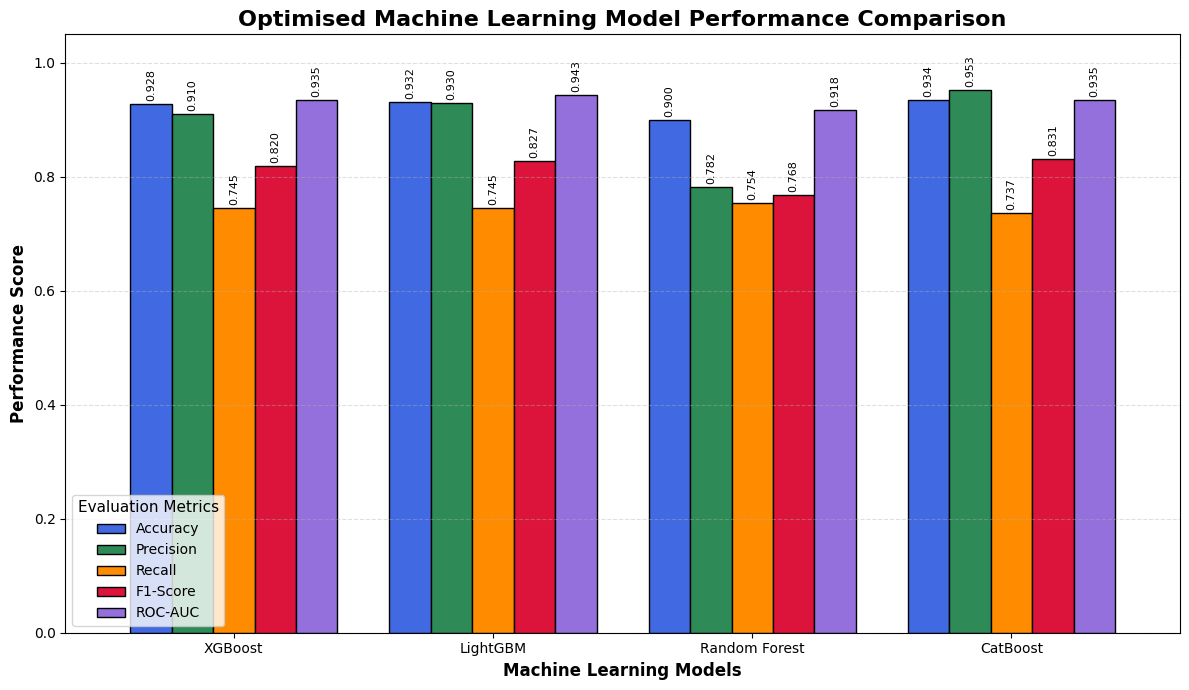

In [ ]:
# I created a comparative performance dataset for the optimised machine learning models.
comparison_df = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM", "Random Forest", "CatBoost"],
    "Accuracy": [
        tun_xg_metric["Accuracy"],
        tun_lgbm_metric["Accuracy"],
        tun_rf_metric["Accuracy"],
        tun_cat_metric["Accuracy"]
    ],
    "Precision": [
        tun_xg_metric["Precision"],
        tun_lgbm_metric["Precision"],
        tun_rf_metric["Precision"],
        tun_cat_metric["Precision"]
    ],
    "Recall": [
        tun_xg_metric["Recall"],
        tun_lgbm_metric["Recall"],
        tun_rf_metric["Recall"],
        tun_cat_metric["Recall"]
    ],
    "F1-Score": [
        tun_xg_metric["F1-Score"],
        tun_lgbm_metric["F1-Score"],
        tun_rf_metric["F1-Score"],
        tun_cat_metric["F1-Score"]
    ],
    "ROC-AUC": [
        tun_xg_metric["ROC-AUC"],
        tun_lgbm_metric["ROC-AUC"],
        tun_rf_metric["ROC-AUC"],
        tun_cat_metric["ROC-AUC"]
    ]
})

# I created a grouped bar chart for comparing the optimised machine learning models.
ax = comparison_df.set_index("Model").plot(
    kind="bar",
    figsize=(12,7),
    width=0.8,
    color=[
        "royalblue",
        "seagreen",
        "darkorange",
        "crimson",
        "mediumpurple"
    ],
    edgecolor="black"
)

# I customised the chart.
plt.title(
    "Optimised Machine Learning Model Performance Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Machine Learning Models",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Performance Score",
    fontsize=12,
    fontweight="bold"
)

plt.ylim(0, 1.05)

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# I displayed the legend.
plt.legend(
    title="Evaluation Metrics",
    fontsize=10,
    title_fontsize=11,
    loc="lower left"
)

# I displayed the metric values above each bar.
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        fontsize=8,
        rotation=90,
        padding=2
    )

# I adjusted the layout.
plt.tight_layout()

# I displayed the grouped bar chart.
plt.show()

# Combined Comparative F1-Score Graph  for all Tuned Models

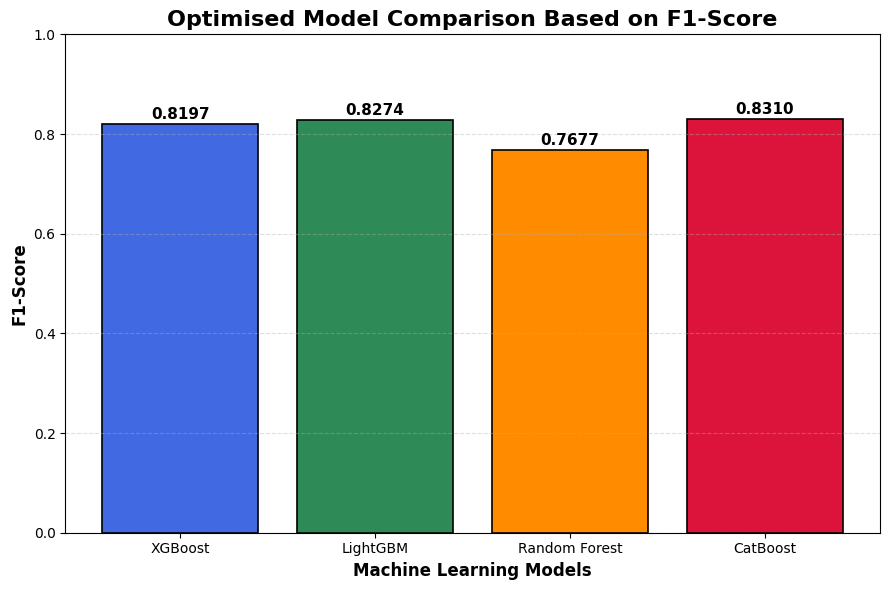

In [ ]:
# I created the F1-Score values for all optimised machine learning models.
models = ["XGBoost", "LightGBM", "Random Forest", "CatBoost"]

f1_scores = [
    tun_xg_metric["F1-Score"],
    tun_lgbm_metric["F1-Score"],
    tun_rf_metric["F1-Score"],
    tun_cat_metric["F1-Score"]
]

# I assigned different colours to each model.
colours = [
    "royalblue",
    "seagreen",
    "darkorange",
    "crimson"
]

# I created the F1-Score comparison bar chart.
plt.figure(figsize=(9,6))

bars = plt.bar(
    models,
    f1_scores,
    color=colours,
    edgecolor="black",
    linewidth=1.2
)

# I displayed the F1-Score values above each bar.
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.4f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# I customised the graph.
plt.title(
    "Optimised Model Comparison Based on F1-Score",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Machine Learning Models",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "F1-Score",
    fontsize=12,
    fontweight="bold"
)

plt.ylim(0, 1.0)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# I adjusted the layout.
plt.tight_layout()

# I displayed the graph.
plt.show()

# Confusion Matrices for all Tuned Models

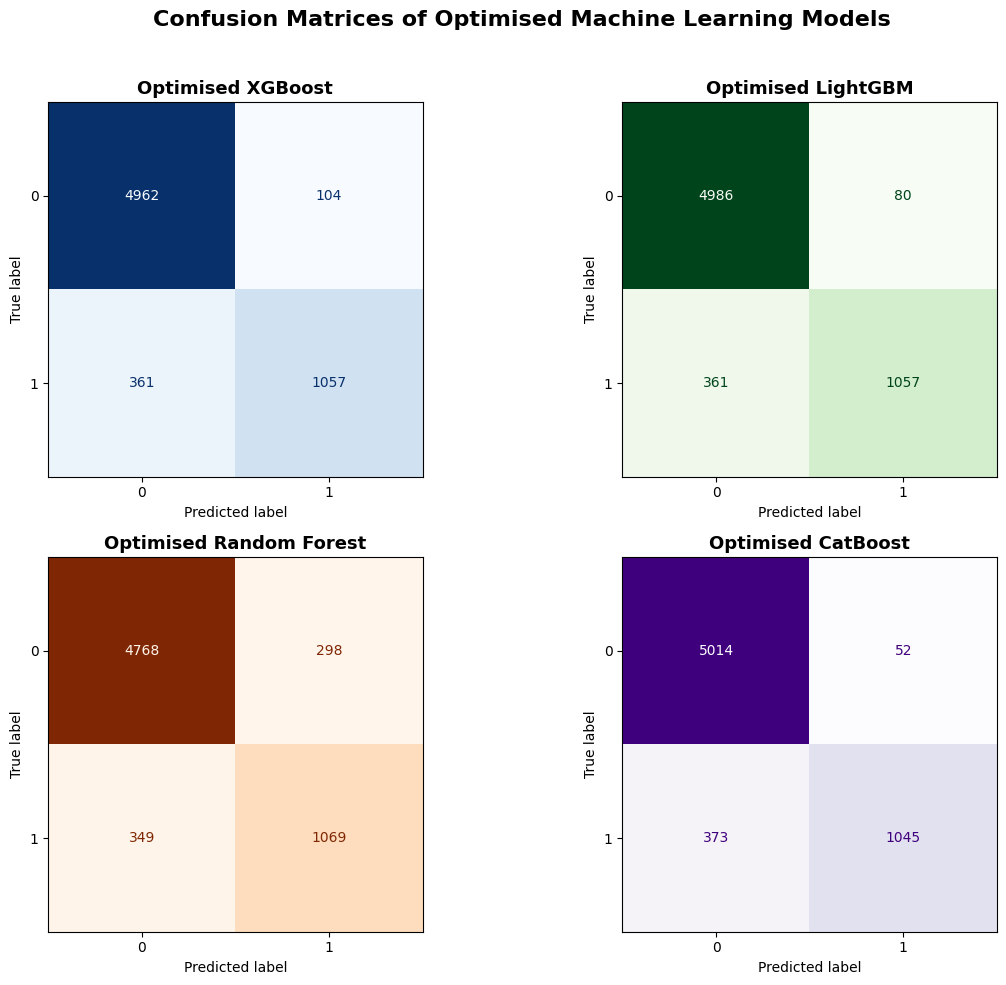

In [ ]:
# I imported the confusion matrix libraries.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# I predicted the class labels using the optimised machine learning models.
xgb_pred = best_xgb.predict(X_test)
lgbm_pred = best_lgbm.predict(X_test)
rf_pred = best_rf.predict(X_test)
cat_pred = best_cat.predict(X_test)

# I calculated the confusion matrices.
xgb_cm = confusion_matrix(y_test, xgb_pred)
lgbm_cm = confusion_matrix(y_test, lgbm_pred)
rf_cm = confusion_matrix(y_test, rf_pred)
cat_cm = confusion_matrix(y_test, cat_pred)

# I created a figure to display all confusion matrices.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# I displayed the XGBoost confusion matrix.
ConfusionMatrixDisplay(xgb_cm).plot(
    ax=axes[0, 0],
    cmap="Blues",
    colorbar=False
)
axes[0, 0].set_title("Optimised XGBoost", fontsize=13, fontweight="bold")

# I displayed the LightGBM confusion matrix.
ConfusionMatrixDisplay(lgbm_cm).plot(
    ax=axes[0, 1],
    cmap="Greens",
    colorbar=False
)
axes[0, 1].set_title("Optimised LightGBM", fontsize=13, fontweight="bold")

# I displayed the Random Forest confusion matrix.
ConfusionMatrixDisplay(rf_cm).plot(
    ax=axes[1, 0],
    cmap="Oranges",
    colorbar=False
)
axes[1, 0].set_title("Optimised Random Forest", fontsize=13, fontweight="bold")

# I displayed the CatBoost confusion matrix.
ConfusionMatrixDisplay(cat_cm).plot(
    ax=axes[1, 1],
    cmap="Purples",
    colorbar=False
)
axes[1, 1].set_title("Optimised CatBoost", fontsize=13, fontweight="bold")

# I added a title to the figure.
plt.suptitle(
    "Confusion Matrices of Optimised Machine Learning Models",
    fontsize=16,
    fontweight="bold"
)

# I adjusted the layout.
plt.tight_layout(rect=[0, 0, 1, 0.96])

# I displayed the confusion matrices.
plt.show()

# Combined AUC-ROC Curve for all Tuned Models

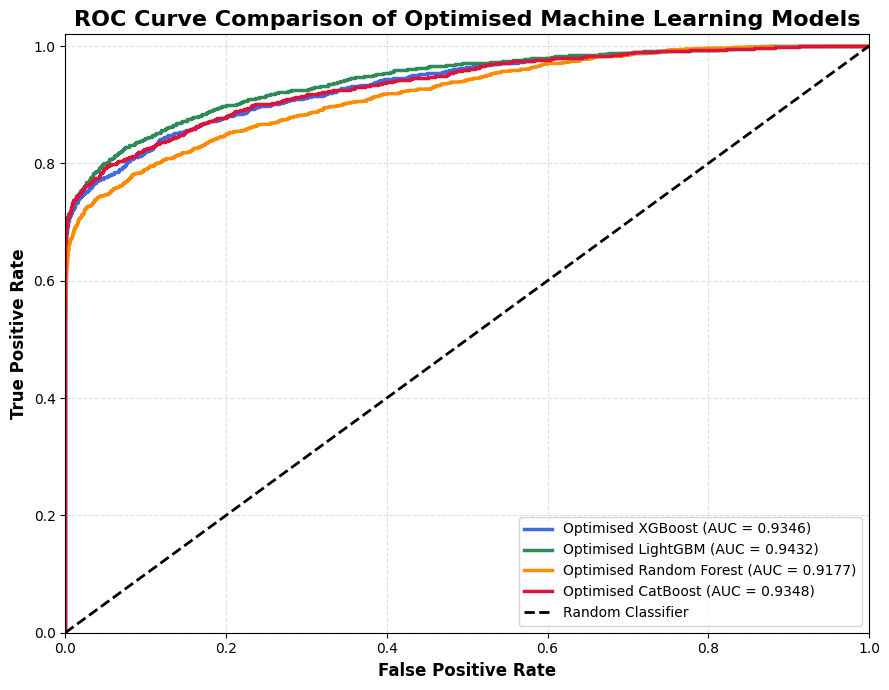

In [ ]:
# I imported the required libraries for plotting the ROC curves.
from sklearn.metrics import roc_curve, auc

# I predicted the probabilities for each optimised machine learning model.
xgb_prob = best_xgb.predict_proba(X_test)[:, 1]
lgbm_prob = best_lgbm.predict_proba(X_test)[:, 1]
rf_prob = best_rf.predict_proba(X_test)[:, 1]
cat_prob = best_cat.predict_proba(X_test)[:, 1]

# I calculated the ROC curve and AUC for the XGBoost model.
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)
xgb_auc = auc(xgb_fpr, xgb_tpr)

# I calculated the ROC curve and AUC for the LightGBM model.
lgbm_fpr, lgbm_tpr, _ = roc_curve(y_test, lgbm_prob)
lgbm_auc = auc(lgbm_fpr, lgbm_tpr)

# I calculated the ROC curve and AUC for the Random Forest model.
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
rf_auc = auc(rf_fpr, rf_tpr)

# I calculated the ROC curve and AUC for the CatBoost model.
cat_fpr, cat_tpr, _ = roc_curve(y_test, cat_prob)
cat_auc = auc(cat_fpr, cat_tpr)

# I created the combined ROC curve.
plt.figure(figsize=(9,7))

plt.plot(
    xgb_fpr,
    xgb_tpr,
    color="royalblue",
    linewidth=2.5,
    label=f"Optimised XGBoost (AUC = {xgb_auc:.4f})"
)

plt.plot(
    lgbm_fpr,
    lgbm_tpr,
    color="seagreen",
    linewidth=2.5,
    label=f"Optimised LightGBM (AUC = {lgbm_auc:.4f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    color="darkorange",
    linewidth=2.5,
    label=f"Optimised Random Forest (AUC = {rf_auc:.4f})"
)

plt.plot(
    cat_fpr,
    cat_tpr,
    color="crimson",
    linewidth=2.5,
    label=f"Optimised CatBoost (AUC = {cat_auc:.4f})"
)

# I plotted the random classifier reference line.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    linewidth=2,
    label="Random Classifier"
)

# I customised the graph.
plt.title(
    "ROC Curve Comparison of Optimised Machine Learning Models",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12,
    fontweight="bold"
)

plt.xlim(0, 1)
plt.ylim(0, 1.02)

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.legend(
    loc="lower right",
    fontsize=10,
    frameon=True
)

# I adjusted the layout.
plt.tight_layout()

# I displayed the ROC curve.
plt.show()

# Combined Comparative Table for Both Baseline and Tuned Models

In [ ]:
# I created a comparative performance table for the baseline and optimised machine learning models.
final_comparison = pd.DataFrame({
    "Model": [
        "XGBoost (Baseline)",
        "XGBoost (Optimised)",
        "LightGBM (Baseline)",
        "LightGBM (Optimised)",
        "Random Forest (Baseline)",
        "Random Forest (Optimised)",
        "CatBoost (Baseline)",
        "CatBoost (Optimised)"
    ],
    "Accuracy": [
        bas_xgb_metric["Accuracy"],
        tun_xg_metric["Accuracy"],
        bas_lgbm_metric["Accuracy"],
        tun_lgbm_metric["Accuracy"],
        bas_rf_metric["Accuracy"],
        tun_rf_metric["Accuracy"],
        bas_cat_metric["Accuracy"],
        tun_cat_metric["Accuracy"]
    ],
    "Precision": [
        bas_xgb_metric["Precision"],
        tun_xg_metric["Precision"],
        bas_lgbm_metric["Precision"],
        tun_lgbm_metric["Precision"],
        bas_rf_metric["Precision"],
        tun_rf_metric["Precision"],
        bas_cat_metric["Precision"],
        tun_cat_metric["Precision"]
    ],
    "Recall": [
        bas_xgb_metric["Recall"],
        tun_xg_metric["Recall"],
        bas_lgbm_metric["Recall"],
        tun_lgbm_metric["Recall"],
        bas_rf_metric["Recall"],
        tun_rf_metric["Recall"],
        bas_cat_metric["Recall"],
        tun_cat_metric["Recall"]
    ],
    "F1-Score": [
        bas_xgb_metric["F1-Score"],
        tun_xg_metric["F1-Score"],
        bas_lgbm_metric["F1-Score"],
        tun_lgbm_metric["F1-Score"],
        bas_rf_metric["F1-Score"],
        tun_rf_metric["F1-Score"],
        bas_cat_metric["F1-Score"],
        tun_cat_metric["F1-Score"]
    ],
    "ROC-AUC": [
        bas_xgb_metric["ROC-AUC"],
        tun_xg_metric["ROC-AUC"],
        bas_lgbm_metric["ROC-AUC"],
        tun_lgbm_metric["ROC-AUC"],
        bas_rf_metric["ROC-AUC"],
        tun_rf_metric["ROC-AUC"],
        bas_cat_metric["ROC-AUC"],
        tun_cat_metric["ROC-AUC"]
    ]
})

# I rounded the evaluation metrics to four decimal places.
final_comparison = final_comparison.round(4)

# I assigned different colours to the baseline and optimised models.
def highlight_rows(row):

    if "Baseline" in row["Model"]:
        return ["background-color:#FFF3CD"] * len(row)   # Light Yellow

    elif "Optimised" in row["Model"]:
        return ["background-color:#D4EDDA"] * len(row)   # Light Green

    return [""] * len(row)

# I displayed the styled comparison table.
final_comparison.style\
    .apply(highlight_rows, axis=1)\
    .hide(axis="index")\
    .set_caption("Comparison of Baseline and Optimised Machine Learning Models")\
    .format({
        "Accuracy":"{:.4f}",
        "Precision":"{:.4f}",
        "Recall":"{:.4f}",
        "F1-Score":"{:.4f}",
        "ROC-AUC":"{:.4f}"
    })\
    .set_properties(**{
        "text-align":"center",
        "border":"1px solid black",
        "font-size":"12pt"
    })\
    .set_table_styles([
        {
            "selector":"caption",
            "props":[
                ("font-size","18px"),
                ("font-weight","bold"),
                ("color","#1F4E78"),
                ("padding","10px"),
                ("text-align","center")
            ]
        },
        {
            "selector":"th",
            "props":[
                ("background-color","#1F4E78"),
                ("color","white"),
                ("font-size","13pt"),
                ("font-weight","bold"),
                ("border","1px solid black"),
                ("text-align","center")
            ]
        },
        {
            "selector":"td",
            "props":[
                ("border","1px solid black"),
                ("text-align","center")
            ]
        }
    ])

Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
XGBoost (Baseline),0.9320,0.9215,0.7532,0.8289,0.9362
XGBoost (Optimised),0.9283,0.9104,0.7454,0.8197,0.9346
LightGBM (Baseline),0.9281,0.9139,0.7412,0.8185,0.9345
LightGBM (Optimised),0.9320,0.9296,0.7454,0.8274,0.9432
Random Forest (Baseline),0.9039,0.7951,0.7553,0.7747,0.9188
Random Forest (Optimised),0.9002,0.7820,0.7539,0.7677,0.9177
CatBoost (Baseline),0.9354,0.9520,0.7419,0.8339,0.9388
CatBoost (Optimised),0.9345,0.9526,0.7370,0.8310,0.9348


# Combined Comparative Bar Graph for Both Baseline and Tuned Models

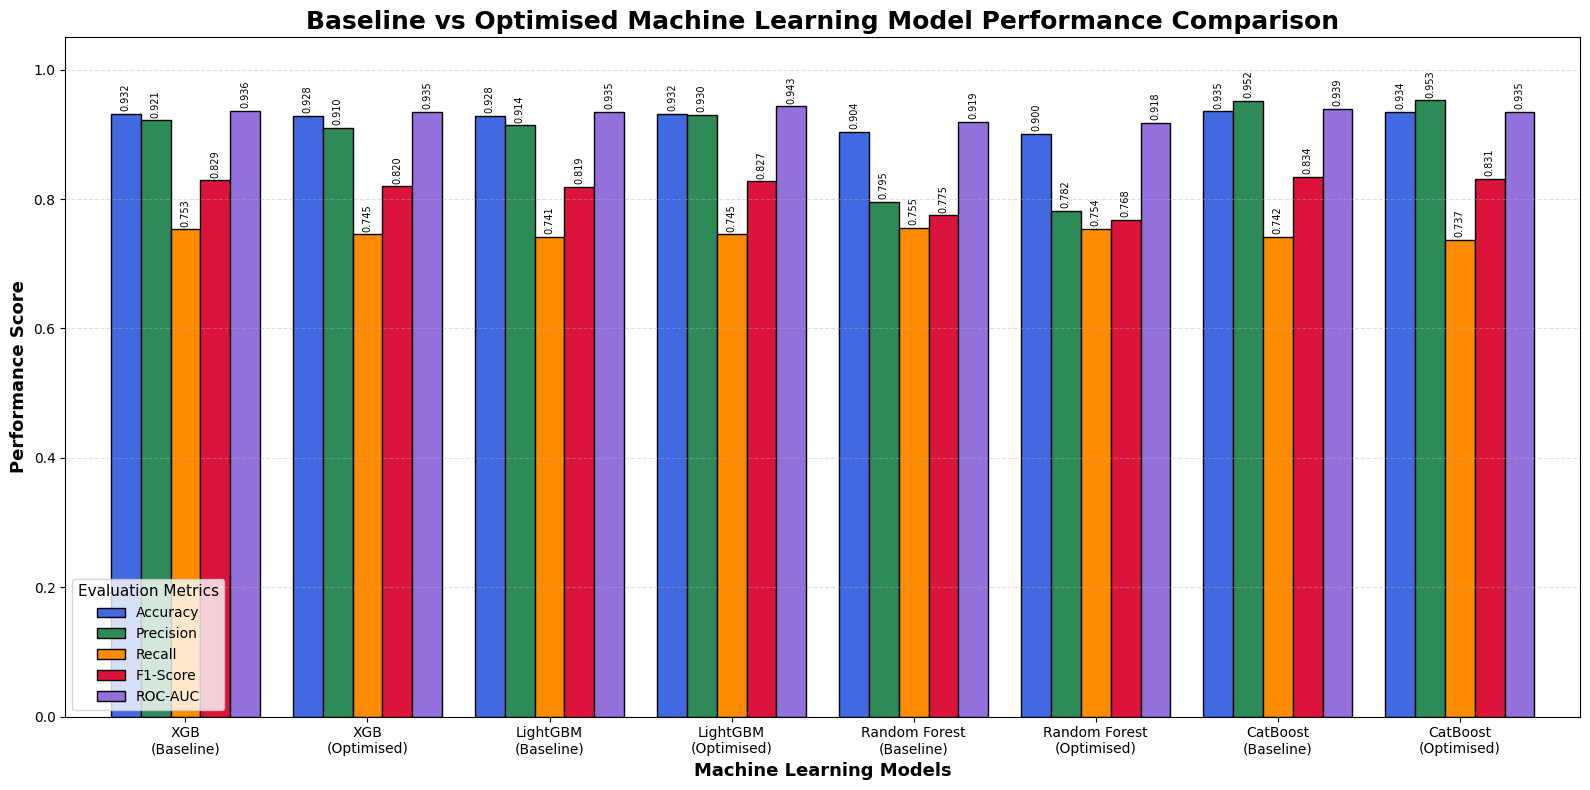

In [ ]:
# I created a comparative dataset for the baseline and optimised machine learning models.
comparison_df = pd.DataFrame({
    "Model": [
        "XGB\n(Baseline)",
        "XGB\n(Optimised)",
        "LightGBM\n(Baseline)",
        "LightGBM\n(Optimised)",
        "Random Forest\n(Baseline)",
        "Random Forest\n(Optimised)",
        "CatBoost\n(Baseline)",
        "CatBoost\n(Optimised)"
    ],
    "Accuracy": [
        bas_xgb_metric["Accuracy"],
        tun_xg_metric["Accuracy"],
        bas_lgbm_metric["Accuracy"],
        tun_lgbm_metric["Accuracy"],
        bas_rf_metric["Accuracy"],
        tun_rf_metric["Accuracy"],
        bas_cat_metric["Accuracy"],
        tun_cat_metric["Accuracy"]
    ],
    "Precision": [
        bas_xgb_metric["Precision"],
        tun_xg_metric["Precision"],
        bas_lgbm_metric["Precision"],
        tun_lgbm_metric["Precision"],
        bas_rf_metric["Precision"],
        tun_rf_metric["Precision"],
        bas_cat_metric["Precision"],
        tun_cat_metric["Precision"]
    ],
    "Recall": [
        bas_xgb_metric["Recall"],
        tun_xg_metric["Recall"],
        bas_lgbm_metric["Recall"],
        tun_lgbm_metric["Recall"],
        bas_rf_metric["Recall"],
        tun_rf_metric["Recall"],
        bas_cat_metric["Recall"],
        tun_cat_metric["Recall"]
    ],
    "F1-Score": [
        bas_xgb_metric["F1-Score"],
        tun_xg_metric["F1-Score"],
        bas_lgbm_metric["F1-Score"],
        tun_lgbm_metric["F1-Score"],
        bas_rf_metric["F1-Score"],
        tun_rf_metric["F1-Score"],
        bas_cat_metric["F1-Score"],
        tun_cat_metric["F1-Score"]
    ],
    "ROC-AUC": [
        bas_xgb_metric["ROC-AUC"],
        tun_xg_metric["ROC-AUC"],
        bas_lgbm_metric["ROC-AUC"],
        tun_lgbm_metric["ROC-AUC"],
        bas_rf_metric["ROC-AUC"],
        tun_rf_metric["ROC-AUC"],
        bas_cat_metric["ROC-AUC"],
        tun_cat_metric["ROC-AUC"]
    ]
})

# I created the grouped bar chart.
ax = comparison_df.set_index("Model").plot(
    kind="bar",
    figsize=(16,8),
    width=0.82,
    color=[
        "royalblue",
        "seagreen",
        "darkorange",
        "crimson",
        "mediumpurple"
    ],
    edgecolor="black"
)

# I customised the graph.
plt.title(
    "Baseline vs Optimised Machine Learning Model Performance Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Machine Learning Models",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Performance Score",
    fontsize=13,
    fontweight="bold"
)

plt.xticks(rotation=0, fontsize=10)

plt.ylim(0, 1.05)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.legend(
    title="Evaluation Metrics",
    fontsize=10,
    title_fontsize=11,
    loc="lower left"
)

# I displayed the metric values above each bar.
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        fontsize=7,
        rotation=90,
        padding=2
    )

# I adjusted the layout.
plt.tight_layout()

# I displayed the graph.
plt.show()

# Combined Comparative F1-Score Garph  for Both Baseline and Tuned Models

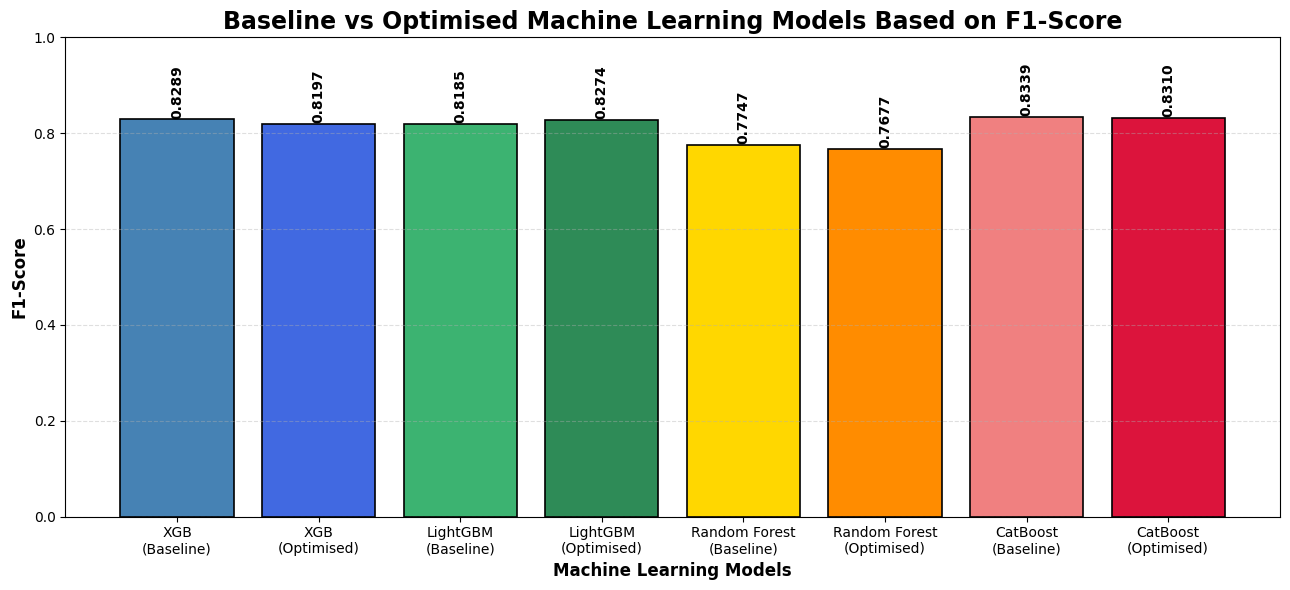

In [ ]:
# I created the F1-Score values for the baseline and optimised machine learning models.
models = [
    "XGB\n(Baseline)",
    "XGB\n(Optimised)",
    "LightGBM\n(Baseline)",
    "LightGBM\n(Optimised)",
    "Random Forest\n(Baseline)",
    "Random Forest\n(Optimised)",
    "CatBoost\n(Baseline)",
    "CatBoost\n(Optimised)"
]

f1_scores = [
    bas_xgb_metric["F1-Score"],
    tun_xg_metric["F1-Score"],
    bas_lgbm_metric["F1-Score"],
    tun_lgbm_metric["F1-Score"],
    bas_rf_metric["F1-Score"],
    tun_rf_metric["F1-Score"],
    bas_cat_metric["F1-Score"],
    tun_cat_metric["F1-Score"]
]

# I assigned different colours to the baseline and optimised models.
colours = [
    "steelblue",
    "royalblue",
    "mediumseagreen",
    "seagreen",
    "gold",
    "darkorange",
    "lightcoral",
    "crimson"
]

# I created the F1-Score comparison bar chart.
plt.figure(figsize=(13,6))

bars = plt.bar(
    models,
    f1_scores,
    color=colours,
    edgecolor="black",
    linewidth=1.2
)

# I displayed the F1-Score values above each bar.
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.008,
        f"{height:.4f}",
        ha="center",
        fontsize=10,
        fontweight="bold",
        rotation=90
    )

# I customised the graph.
plt.title(
    "Baseline vs Optimised Machine Learning Models Based on F1-Score",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel(
    "Machine Learning Models",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "F1-Score",
    fontsize=12,
    fontweight="bold"
)

plt.ylim(0, 1.0)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# I adjusted the layout.
plt.tight_layout()

# I displayed the graph.
plt.show()

# Best Performing Model

In [ ]:
# I created a dictionary containing all trained machine learning models.
all_models = {
    "XGBoost": (best_xgb, tun_xg_metric),
    "LightGBM": (best_lgbm, tun_lgbm_metric),
    "Random Forest": (best_rf, tun_rf_metric),
    "CatBoost": (best_cat, tun_cat_metric)
}

# I selected the best-performing machine learning model based on the highest F1-Score.
best_model_name = max(
    all_models,
    key=lambda model: all_models[model][1]["F1-Score"]
)

# I retrieved the best-performing model and its evaluation metrics.
final_model = all_models[best_model_name][0]
final_metric = all_models[best_model_name][1]

# I displayed the best-performing machine learning model.
print("Best Performing Machine Learning Model")

print(f"Selected Model : {best_model_name}")
print(f"Accuracy       : {final_metric['Accuracy']:.4f}")
print(f"Precision      : {final_metric['Precision']:.4f}")
print(f"Recall         : {final_metric['Recall']:.4f}")
print(f"F1-Score       : {final_metric['F1-Score']:.4f}")
print(f"ROC-AUC        : {final_metric['ROC-AUC']:.4f}")

Best Performing Machine Learning Model
Selected Model : CatBoost
Accuracy       : 0.9345
Precision      : 0.9526
Recall         : 0.7370
F1-Score       : 0.8310
ROC-AUC        : 0.9348


# Saving the Best Model

In [ ]:
# I imported the joblib library.
import joblib

# I saved the best-performing machine learning model.
joblib.dump(final_model, "credit_prediction_model.pkl")


['credit_prediction_model.pkl']

In [ ]:
# I saved the fitted label encoders.
joblib.dump(label_encoders, "credit_label_encoders.pkl")

['credit_label_encoders.pkl']

# SHAP Analysis Based on Best Performing Model

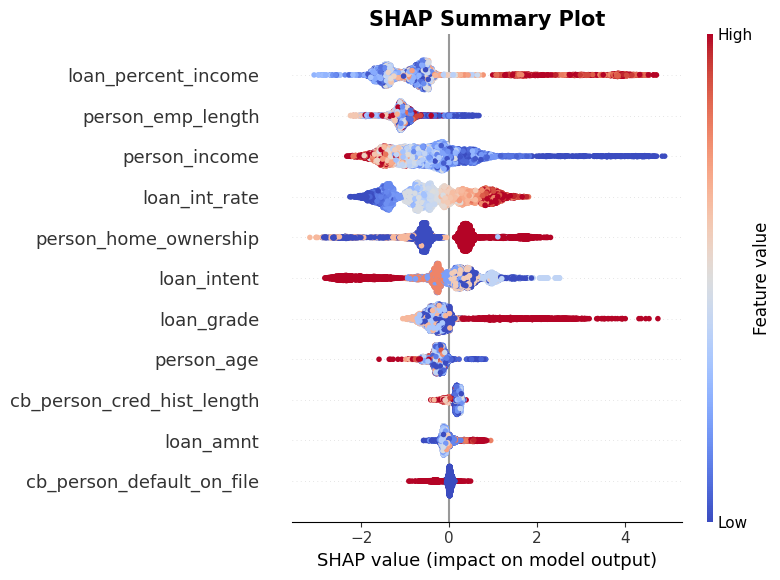

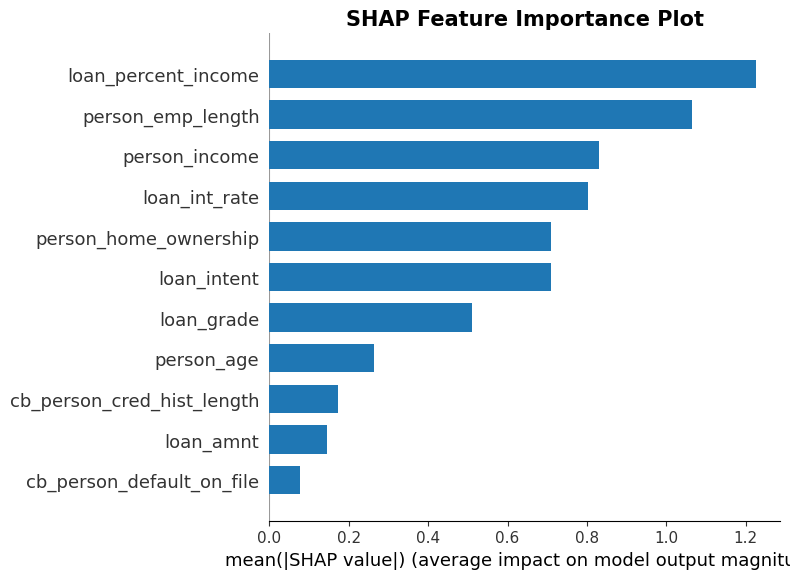

In [ ]:
# I imported the required libraries for SHAP analysis.
import shap
import matplotlib.pyplot as plt

# I created a SHAP TreeExplainer for the best-performing machine learning model.
explainer = shap.TreeExplainer(final_model)

# I calculated the SHAP values for the complete testing dataset.
shap_values = explainer.shap_values(
    X_test,
    check_additivity=False
)


# SHAP Summary Plot


plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns.tolist(),
    cmap="coolwarm",
    show=False
)

plt.title(
    "SHAP Summary Plot",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# SHAP Feature Importance Plot


plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns.tolist(),
    plot_type="bar",
    color="#1f77b4",
    show=False
)

plt.title(
    "SHAP Feature Importance Plot",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# Interface For Human Evaluation : FeedBack Collection

In [ ]:
import tkinter as tk
from tkinter import ttk, messagebox
import pandas as pd
import numpy as np
import joblib
import csv
import os



model = joblib.load("credit_prediction_model.pkl")
label_encoders = joblib.load("credit_label_encoders.pkl")



root = tk.Tk()
root.title("Customer Credit Risk Prediction Prototype")
root.geometry("1200x850")
root.configure(bg="#EEF6FF")



canvas = tk.Canvas(root, bg="#EEF6FF", highlightthickness=0)
scrollbar = ttk.Scrollbar(root, orient="vertical", command=canvas.yview)

main_frame = tk.Frame(canvas, bg="#EEF6FF")

main_frame.bind(
    "<Configure>",
    lambda e: canvas.configure(scrollregion=canvas.bbox("all"))
)

canvas.create_window((0, 0), window=main_frame, anchor="nw")
canvas.configure(yscrollcommand=scrollbar.set)

canvas.pack(side="left", fill="both", expand=True)
scrollbar.pack(side="right", fill="y")


header = tk.Frame(
    main_frame,
    bg="#0B5ED7",
    height=80
)

header.pack(fill="x")

title = tk.Label(
    header,
    text="Customer Credit Risk Prediction Prototype",
    bg="#0B5ED7",
    fg="white",
    font=("Segoe UI",22,"bold")
)

title.pack(pady=18)

subtitle = tk.Label(
    main_frame,
    text="Enter Customer Information",
    bg="#EEF6FF",
    fg="#0B5ED7",
    font=("Segoe UI",18,"bold")
)

subtitle.pack(pady=20)


input_frame = tk.LabelFrame(
    main_frame,
    text="Customer Information",
    font=("Segoe UI",14,"bold"),
    bg="white",
    padx=20,
    pady=20
)

input_frame.pack(fill="x", padx=30)



person_age = tk.StringVar()
person_income = tk.StringVar()
person_home_ownership = tk.StringVar()
person_emp_length = tk.StringVar()

loan_intent = tk.StringVar()
loan_grade = tk.StringVar()
loan_amnt = tk.StringVar()
loan_int_rate = tk.StringVar()

loan_percent_income = tk.StringVar()
cb_person_default_on_file = tk.StringVar()
cb_person_cred_hist_length = tk.StringVar()


tk.Label(input_frame,text="Age",bg="white",
font=("Segoe UI",11,"bold")).grid(row=0,column=0,pady=8,sticky="w")

tk.Entry(input_frame,textvariable=person_age,width=28,
font=("Segoe UI",11)).grid(row=0,column=1,padx=15)


tk.Label(input_frame,text="Annual Income",bg="white",
font=("Segoe UI",11,"bold")).grid(row=1,column=0,pady=8,sticky="w")

tk.Entry(input_frame,textvariable=person_income,width=28,
font=("Segoe UI",11)).grid(row=1,column=1,padx=15)


tk.Label(input_frame,text="Home Ownership",bg="white",
font=("Segoe UI",11,"bold")).grid(row=2,column=0,pady=8,sticky="w")

home_combo=ttk.Combobox(
input_frame,
textvariable=person_home_ownership,
width=25,
state="readonly",
values=["MORTGAGE","OWN","RENT","OTHER"]
)

home_combo.grid(row=2,column=1,padx=15)
home_combo.current(0)


tk.Label(input_frame,text="Employment Length",
bg="white",
font=("Segoe UI",11,"bold")).grid(row=3,column=0,pady=8,sticky="w")

tk.Entry(
input_frame,
textvariable=person_emp_length,
width=28,
font=("Segoe UI",11)
).grid(row=3,column=1,padx=15)



tk.Label(input_frame,text="Loan Intent",
bg="white",
font=("Segoe UI",11,"bold")).grid(row=0,column=2,padx=50,sticky="w")

intent_combo=ttk.Combobox(
input_frame,
textvariable=loan_intent,
width=25,
state="readonly",
values=[
"EDUCATION",
"MEDICAL",
"PERSONAL",
"VENTURE",
"HOMEIMPROVEMENT",
"DEBTCONSOLIDATION"
]
)

intent_combo.grid(row=0,column=3)
intent_combo.current(0)


tk.Label(input_frame,text="Loan Grade",
bg="white",
font=("Segoe UI",11,"bold")).grid(row=1,column=2,padx=50,sticky="w")

grade_combo=ttk.Combobox(
input_frame,
textvariable=loan_grade,
width=25,
state="readonly",
values=["A","B","C","D","E","F","G"]
)

grade_combo.grid(row=1,column=3)
grade_combo.current(0)


tk.Label(input_frame,text="Loan Amount",
bg="white",
font=("Segoe UI",11,"bold")).grid(row=2,column=2,padx=50,sticky="w")

tk.Entry(
input_frame,
textvariable=loan_amnt,
width=28,
font=("Segoe UI",11)
).grid(row=2,column=3)


tk.Label(input_frame,text="Interest Rate",
bg="white",
font=("Segoe UI",11,"bold")).grid(row=3,column=2,padx=50,sticky="w")

tk.Entry(
input_frame,
textvariable=loan_int_rate,
width=28,
font=("Segoe UI",11)
).grid(row=3,column=3)


tk.Label(input_frame,text="Loan Percent Income",
bg="white",
font=("Segoe UI",11,"bold")).grid(row=4,column=0,pady=10,sticky="w")

tk.Entry(
input_frame,
textvariable=loan_percent_income,
width=28,
font=("Segoe UI",11)
).grid(row=4,column=1)


tk.Label(input_frame,text="Previous Default",
bg="white",
font=("Segoe UI",11,"bold")).grid(row=4,column=2,padx=50,sticky="w")

default_combo=ttk.Combobox(
input_frame,
textvariable=cb_person_default_on_file,
width=25,
state="readonly",
values=["N","Y"]
)

default_combo.grid(row=4,column=3)
default_combo.current(0)


tk.Label(input_frame,text="Credit History Length",
bg="white",
font=("Segoe UI",11,"bold")).grid(row=5,column=0,pady=10,sticky="w")

tk.Entry(
input_frame,
textvariable=cb_person_cred_hist_length,
width=28,
font=("Segoe UI",11)
).grid(row=5,column=1)



result_frame = tk.LabelFrame(
main_frame,
text="Prediction Result",
font=("Segoe UI",14,"bold"),
bg="white",
padx=20,
pady=20
)

result_frame.pack(fill="x",padx=30,pady=20)

prediction_label=tk.Label(
result_frame,
text="Prediction will appear here",
font=("Segoe UI",18,"bold"),
bg="white",
fg="#0B5ED7"
)

prediction_label.pack()

confidence_label=tk.Label(
result_frame,
text="Confidence : -- %",
font=("Segoe UI",12),
bg="white"
)

confidence_label.pack(pady=5)



def predict_credit_risk():

    try:

        # I validated the numeric inputs.
        age = int(person_age.get())
        income = float(person_income.get())
        emp_length = float(person_emp_length.get())
        loan_amount = float(loan_amnt.get())
        interest_rate = float(loan_int_rate.get())
        percent_income = float(loan_percent_income.get())
        credit_history = float(cb_person_cred_hist_length.get())

        # I validated that the numeric values were positive.
        if age <= 0 or income <= 0 or loan_amount <= 0:
            messagebox.showwarning(
                "Invalid Input",
                "Please enter valid positive values."
            )
            return

        # I created the customer information.
        customer = pd.DataFrame({
            "person_age":[age],
            "person_income":[income],
            "person_home_ownership":[person_home_ownership.get()],
            "person_emp_length":[emp_length],
            "loan_intent":[loan_intent.get()],
            "loan_grade":[loan_grade.get()],
            "loan_amnt":[loan_amount],
            "loan_int_rate":[interest_rate],
            "loan_percent_income":[percent_income],
            "cb_person_default_on_file":[cb_person_default_on_file.get()],
            "cb_person_cred_hist_length":[credit_history]
        })

        # I encoded the categorical features.
        categorical_columns = [
            "person_home_ownership",
            "loan_intent",
            "loan_grade",
            "cb_person_default_on_file"
        ]

        for column in categorical_columns:

            customer[column] = label_encoders[column].transform(
                customer[column]
            )

        # I predicted the customer credit risk.
        prediction = model.predict(customer)[0]

        # I calculated the prediction confidence.
        probability = model.predict_proba(customer)

        confidence = np.max(probability) * 100

        # I displayed the prediction.
        if prediction == 1:

            prediction_label.config(
                text="HIGH CREDIT RISK",
                fg="red"
            )

        else:

            prediction_label.config(
                text="LOW CREDIT RISK",
                fg="green"
            )

        confidence_label.config(
            text=f"Prediction Confidence : {confidence:.2f}%"
        )

    except ValueError:

        messagebox.showerror(
            "Input Error",
            "Please enter valid numeric values."
        )

    except Exception as error:

        messagebox.showerror(
            "Prediction Error",
            str(error)
        )


# I created a function to clear all input fields.
def reset_fields():

    person_age.set("")
    person_income.set("")
    person_home_ownership.set("MORTGAGE")
    person_emp_length.set("")

    loan_intent.set("EDUCATION")
    loan_grade.set("A")
    loan_amnt.set("")
    loan_int_rate.set("")

    loan_percent_income.set("")
    cb_person_default_on_file.set("N")
    cb_person_cred_hist_length.set("")

    prediction_label.config(
        text="Prediction will appear here",
        fg="#0B5ED7"
    )

    confidence_label.config(
        text="Confidence : -- %"
    )



button_frame = tk.Frame(
    main_frame,
    bg="#EEF6FF"
)

button_frame.pack(pady=20)



predict_button = tk.Button(

    button_frame,

    text="Predict Credit Risk",

    command=predict_credit_risk,

    bg="#198754",

    fg="white",

    activebackground="#157347",

    activeforeground="white",

    font=("Segoe UI",12,"bold"),

    width=20,

    height=2,

    cursor="hand2"

)

predict_button.grid(
    row=0,
    column=0,
    padx=15
)



reset_button = tk.Button(

    button_frame,

    text="Reset",

    command=reset_fields,

    bg="#FFC107",

    fg="black",

    activebackground="#E0A800",

    font=("Segoe UI",12,"bold"),

    width=15,

    height=2,

    cursor="hand2"

)

reset_button.grid(
    row=0,
    column=1,
    padx=15
)



exit_button = tk.Button(

    button_frame,

    text="Exit",

    command=root.destroy,

    bg="#DC3545",

    fg="white",

    activebackground="#BB2D3B",

    activeforeground="white",

    font=("Segoe UI",12,"bold"),

    width=15,

    height=2,

    cursor="hand2"

)

exit_button.grid(
    row=0,
    column=2,
    padx=15
)




from datetime import datetime



evaluation_frame = tk.LabelFrame(
    main_frame,
    text="Human Evaluation Questionnaire",
    font=("Segoe UI",14,"bold"),
    bg="white",
    padx=20,
    pady=20
)

evaluation_frame.pack(
    fill="x",
    padx=30,
    pady=20
)



participant_id = tk.StringVar()

tk.Label(
    evaluation_frame,
    text="Participant ID",
    bg="white",
    font=("Segoe UI",11,"bold")
).grid(row=0,column=0,sticky="w",pady=8)

tk.Entry(
    evaluation_frame,
    textvariable=participant_id,
    width=30,
    font=("Segoe UI",11)
).grid(row=0,column=1,padx=10)



ratings = [
    "1 - Strongly Disagree",
    "2 - Disagree",
    "3 - Neutral",
    "4 - Agree",
    "5 - Strongly Agree"
]

q1 = tk.StringVar(value=ratings[4])
q2 = tk.StringVar(value=ratings[4])
q3 = tk.StringVar(value=ratings[4])
q4 = tk.StringVar(value=ratings[4])
q5 = tk.StringVar(value=ratings[4])

questions = [

"The prototype was easy to use.",

"The prediction result was easy to understand.",

"The interface design was visually appealing.",

"The prediction was generated quickly.",

"I am satisfied with the overall prototype."

]

variables = [q1,q2,q3,q4,q5]



for i in range(5):

    tk.Label(
        evaluation_frame,
        text=questions[i],
        bg="white",
        font=("Segoe UI",11)
    ).grid(
        row=i+1,
        column=0,
        sticky="w",
        pady=8
    )

    ttk.Combobox(

        evaluation_frame,

        width=30,

        state="readonly",

        values=ratings,

        textvariable=variables[i]

    ).grid(
        row=i+1,
        column=1,
        padx=10
    )



tk.Label(

    evaluation_frame,

    text="Additional Comments",

    bg="white",

    font=("Segoe UI",11,"bold")

).grid(
    row=6,
    column=0,
    sticky="nw",
    pady=15
)

comments_box = tk.Text(

    evaluation_frame,

    width=60,

    height=6,

    font=("Segoe UI",10)

)

comments_box.grid(
    row=6,
    column=1,
    padx=10
)


def save_feedback():

    if participant_id.get().strip()=="":

        messagebox.showwarning(

            "Missing Information",

            "Please enter Participant ID."

        )

        return

    feedback = {

        "Date":datetime.now().strftime("%Y-%m-%d"),

        "Time":datetime.now().strftime("%H:%M:%S"),

        "Participant ID":participant_id.get(),

        "Ease of Use":q1.get(),

        "Easy to Understand":q2.get(),

        "Visual Design":q3.get(),

        "Prediction Speed":q4.get(),

        "Overall Satisfaction":q5.get(),

        "Comments":comments_box.get("1.0","end").strip()

    }

    file_name="credit_feedback.csv"

    df_feedback=pd.DataFrame([feedback])

    if os.path.exists(file_name):

        df_feedback.to_csv(

            file_name,

            mode="a",

            header=False,

            index=False

        )

    else:

        df_feedback.to_csv(

            file_name,

            index=False

        )

    messagebox.showinfo(

        "Feedback Saved",

        "Thank you.\nYour feedback has been recorded successfully."

    )

    participant_id.set("")

    comments_box.delete("1.0","end")



save_button = tk.Button(

    evaluation_frame,

    text="Submit Evaluation",

    command=save_feedback,

    bg="#0D6EFD",

    fg="white",

    font=("Segoe UI",12,"bold"),

    width=22,

    cursor="hand2"

)

save_button.grid(

    row=7,

    column=1,

    pady=20
)



root.mainloop()